![title](moto.png)

## Links to the data we use in this research

- World Bank Open Data, Labor Force Participation Rate by Gender : https://genderdata.worldbank.org/en/indicator/sl-tlf-acti-zs?utm_source=chatgpt.com
- World Bank Open Data, Ration of female to male labour forcce participation rate : https://data.worldbank.org/indicator/SL.TLF.CACT.FM.ZS?end=2023&most_recent_value_desc=true&start=2023&type=shaded&utm_source=chatgpt.com&view=map&year=2023
- World Bank Open Data, Population number : https://genderdata.worldbank.org/en/indicator/sp-pop?utm_source=chatgpt.com
- Eurostat, Population by sex, age, citizenship and labour status : https://ec.europa.eu/eurostat/databrowser/view/lfsa_pganws/default/table?lang=en&category=mi.mii.mii_emp
- US Bureau of labor statistics, Labor force characteristics by race and ethnicity, 2021 : https://www.bls.gov/opub/reports/race-and-ethnicity/2021/

## Code work ahead!
yeah, I sure hope it does

In [114]:
from sklearn.linear_model import LinearRegression 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# let's load data from the first link
df_labour = pd.read_csv("data/labor-force-participation-rate-of-population/Labor force participation rate (% of population) .csv")

df_labour

,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation
0,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2023,64.487,"female, Modeled, 15+"
1,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2022,64.218,"female, Modeled, 15+"
2,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2021,64.059,"female, Modeled, 15+"
3,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2020,63.535,"female, Modeled, 15+"
4,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2019,64.309,"female, Modeled, 15+"
...,...,...,...,...,...,...,...
98836,"Labor force participation rate, total (% of to...",SL.TLF.ACTI.ZS,Zimbabwe,ZWE,1995,67.420,"total, Modeled, 15-64"
98837,"Labor force participation rate, total (% of to...",SL.TLF.ACTI.ZS,Zimbabwe,ZWE,1994,67.607,"total, Modeled, 15-64"
98838,"Labor force participation rate, total (% of to...",SL.TLF.ACTI.ZS,Zimbabwe,ZWE,1993,67.740,"total, Modeled, 15-64"
98839,"Labor force participation rate, total (% of to...",SL.TLF.ACTI.ZS,Zimbabwe,ZWE,1992,67.902,"total, Modeled, 15-64"


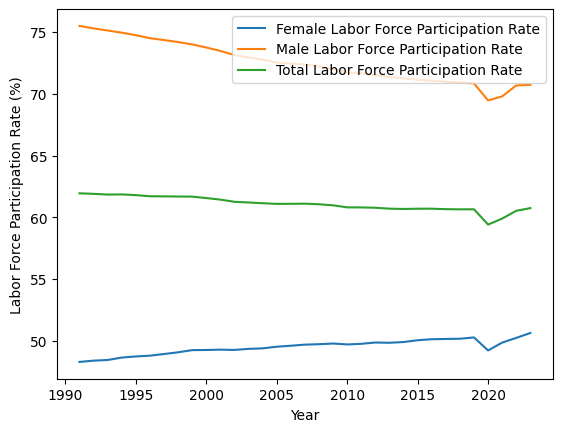

In [197]:
FemaleIndicator = 'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)'
MaleIndicator = 'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)'
TotalIndicator = 'Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)'
yFem = []
xFem = xMasc = xTot = range(1991,2024)
yMasc = []
yTot = []

for i in range(1991,2024):
    yFem.append(df_labour[(df_labour['Indicator Name']==FemaleIndicator) & (df_labour['Year']==i)]['Value'].mean())
for i in range(1991,2024):
    yMasc.append(df_labour[(df_labour['Indicator Name']==MaleIndicator) & (df_labour['Year']==i)]['Value'].mean())
for i in range(1991,2024):
    yTot.append(df_labour[(df_labour['Indicator Name']==TotalIndicator) & (df_labour['Year']==i)]['Value'].mean())

plt.plot(xFem, yFem, label='Female Labor Force Participation Rate')
plt.plot(xFem, yMasc, label='Male Labor Force Participation Rate')
plt.plot(xFem, yTot, label='Total Labor Force Participation Rate')

plt.xlabel('Year')
plt.ylabel('Labor Force Participation Rate (%)')
plt.legend()

Построим регрессию для этих графиков чтобы посмотреть тенденцию

Female model coef is equal to [0.05623761]
Male model coef is equal to [-0.17076865]
Total model coef is equal to [-0.05591397]


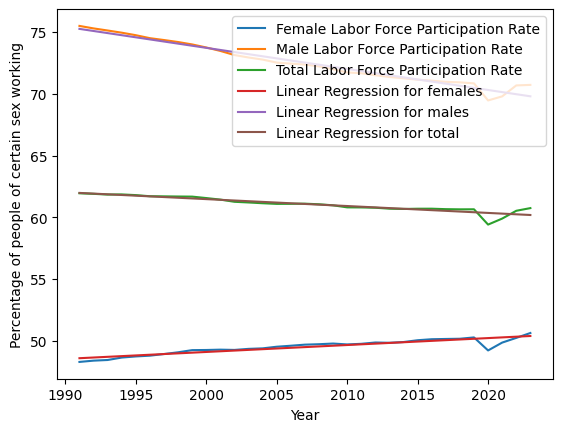

In [204]:

x = np.array(xTot).astype(float).reshape(-1, 1)
model_regression = LinearRegression()
model_regression.fit(x, yFem)
yFem_pred = model_regression.predict(x)
print('Female model coef is equal to ' + str(model_regression.coef_))

model_regression.fit(x, yMasc)
yMasc_pred = model_regression.predict(x)
print('Male model coef is equal to ' + str(model_regression.coef_))

model_regression.fit(x, yTot)
yTot_pred = model_regression.predict(x)
print('Total model coef is equal to ' + str(model_regression.coef_))

plt.plot(xFem, yFem, label='Female Labor Force Participation Rate')
plt.plot(xFem, yMasc, label='Male Labor Force Participation Rate')
plt.plot(xFem, yTot, label='Total Labor Force Participation Rate')

plt.plot(x, yFem_pred, label='Linear Regression for females')
plt.plot(x, yMasc_pred, label='Linear Regression for males')
plt.plot(x, yTot_pred, label='Linear Regression for total')

# Adding labels and legend
plt.xlabel('Year')
plt.ylabel('Percentage of people of certain sex working')
plt.legend()

Как можно увидеть по графикам и коэффициентам, показатели мужчин и данных по обоим полам имеют отрицательную тенденцию, в то время как женщины наоборот

In [35]:
df_labour_US = df_labour[(df_labour['Country Name'] == 'United States') & (df_labour['Indicator Name'] == 'Labor force participation rate, total (% of total population ages 15+) (national estimate)')]
df_labour_US

,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation
38912,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,2023,62.604,"total, National, 15+"
38913,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,2022,62.236,"total, National, 15+"
38914,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,2021,61.659,"total, National, 15+"
38915,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,2020,61.746,"total, National, 15+"
38916,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,2019,63.100,"total, National, 15+"
...,...,...,...,...,...,...,...
38971,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,1964,58.700,"total, National, 15+"
38972,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,1963,58.700,"total, National, 15+"
38973,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,1962,58.800,"total, National, 15+"
38974,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,United States,USA,1961,59.300,"total, National, 15+"


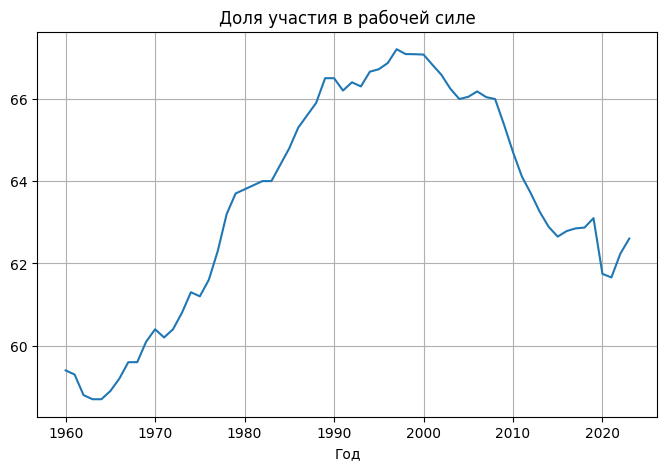

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(df_labour_US['Year'], df_labour_US['Value'])
plt.title('Доля участия в рабочей силе')
plt.xlabel('Год')
plt.grid(True)
plt.show()

In [37]:
# let's load data from the second link
df_f2mratio = pd.read_csv("data/API_SL/Ratio of female to male labor force participation rate.csv",sep=';')

df_f2mratio.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,1990,1991,1992,1993,1994,1995,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
230,Samoa,WSM,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,63.060467,62.973549,62.829590,62.576572,62.419951,62.106370,...,61.124507,61.211156,61.4380928347707,61.452547,60.540159,59.805875,58.949143,58.236856,55.114209,55.720027
231,"Yemen, Rep.",YEM,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,22.151294,22.357774,22.723393,22.774270,23.072344,24.411626,...,8.912051,8.900398,8.7353633945063,8.599781,8.506404,8.425676,8.418072,8.446326,8.219246,8.135934
232,South Africa,ZAF,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,67.374116,67.602412,67.552620,67.895547,67.966589,67.634628,...,78.111690,78.409126,78.0393593795325,79.307521,79.213294,79.762982,79.457130,79.476542,80.078402,81.971504
233,Zambia,ZMB,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,73.976978,74.083675,74.169141,74.226477,74.237357,74.207447,...,78.090015,78.530569,79.0270829214884,79.577142,80.161109,77.645132,80.522748,81.623390,82.655109,82.842045
234,Zimbabwe,ZWE,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,78.554852,79.180321,78.967844,78.646904,79.157296,79.983468,...,82.510538,82.656156,82.9626279653003,83.391599,83.896312,84.432795,83.771955,83.832060,83.350533,83.670293


In [38]:
# let's load data from the third link
df_population = pd.read_csv("data/population-number/Population (number).csv")
df_population.head()

,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation
0,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2023,379025748.0,"female, All ages"
1,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2022,369655503.0,"female, All ages"
2,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2021,360249371.0,"female, All ages"
3,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2020,350869705.0,"female, All ages"
4,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2019,341569862.0,"female, All ages"


In [39]:
# let's load data from the fourth link
df_EU = pd.read_csv('data/EU-employment of migrats.tsv',sep='\t')
df_EU_metadata = df_EU[df_EU.columns[0]].str.split(',', expand=True)
df_EU_metadata.columns = df_EU.columns[0].split(',')
df_EU = df_EU.drop(df_EU.columns[0], axis=1)
df_EU.columns = df_EU.columns.str.strip()
df_EU = df_EU_metadata.join(df_EU)
df_EU = df_EU.replace({r'.*:.*': np.nan}, regex=True)
df_EU = df_EU.replace({r'(\d+)\s+\D+': r'\1'}, regex=True)
df_EU

,freq,unit,sex,citizen,age,wstatus,geo\TIME_PERIOD,1995,1996,1997,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,AT,NaN,NaN,NaN,...,3.5,NaN,3.2,NaN,3.3,4.3,4.2,4.2,5.7,5.6
1,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,BE,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.3,NaN,NaN,NaN,NaN
2,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,CH,NaN,10.3,15.1,...,8.5,9.3,10.2,11.5,12.9,11.2,12.2,11.1,9.7,11.9
3,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,CY,NaN,NaN,NaN,...,NaN,NaN,NaN,0.7,NaN,NaN,NaN,NaN,NaN,0.6
4,A,THS_PER,F,EU27_2020_FOR,Y15-19,ACT,CZ,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122320,A,THS_PER,T,TOTAL,Y_GE75,POP,SI,NaN,78.3,87.2,...,170.0,172.6,176.9,179.7,189.0,194.2,187.6,168.5,169.7,175.5
122321,A,THS_PER,T,TOTAL,Y_GE75,POP,SK,NaN,NaN,NaN,...,299.7,305.6,312.3,320.3,327.3,334.3,344.5,326.3,323.6,334.9
122322,A,THS_PER,T,TOTAL,Y_GE75,POP,TR,NaN,NaN,NaN,...,2469.3,2526.4,2642.1,2587.2,2668.6,2736.2,2846.2,2922.8,2970.6,3060.2
122323,A,THS_PER,T,TOTAL,Y_GE75,POP,UK,3660.3,3759.8,3834.4,...,4865.6,4929.1,4972.0,5053.7,5180.7,5337.8,NaN,NaN,NaN,NaN


In [40]:
# let's load data from the fifth link that was parsed
df_US = pd.read_csv('data/Labor force characteristics by race and ethnicity.csv')
df_US

,Year,"Total, total","Total, male","Total, female","White, total","White, male","White, female","Black or African American, total","Black or African American, male","Black or African American, female","Asian, total","Asian, male","Asian, female","Hispanic or Latino ethnicity, total","Hispanic or Latino ethnicity, male","Hispanic or Latino ethnicity, female"
0,1972,60.4,78.9,43.9,60.4,79.6,43.2,59.9,73.6,48.7,-,-,-,-,-,-
1,1973,60.8,78.8,44.7,60.8,79.4,44.1,60.2,73.4,49.3,-,-,-,60.2,81.5,41.0
2,1974,61.3,78.7,45.7,61.4,79.4,45.2,59.8,72.9,49.0,-,-,-,61.1,81.7,42.4
3,1975,61.2,77.9,46.3,61.5,78.7,45.9,58.8,70.9,48.8,-,-,-,60.8,80.7,43.2
4,1976,61.6,77.5,47.3,61.8,78.4,46.9,59.0,70.0,49.8,-,-,-,60.8,79.6,44.3
5,1977,62.3,77.7,48.4,62.5,78.5,48.0,59.8,70.6,50.8,-,-,-,61.6,80.9,44.3
6,1978,63.2,77.9,50.0,63.3,78.6,49.4,61.5,71.5,53.1,-,-,-,62.9,81.1,46.6
7,1979,63.7,77.8,50.9,63.9,78.6,50.5,61.4,71.3,53.1,-,-,-,63.6,81.3,47.4
8,1980,63.8,77.4,51.5,64.1,78.2,51.2,61.0,70.3,53.1,-,-,-,64.0,81.4,47.4
9,1981,63.9,77.0,52.1,64.3,77.9,51.9,60.8,70.0,53.5,-,-,-,64.1,80.6,48.3


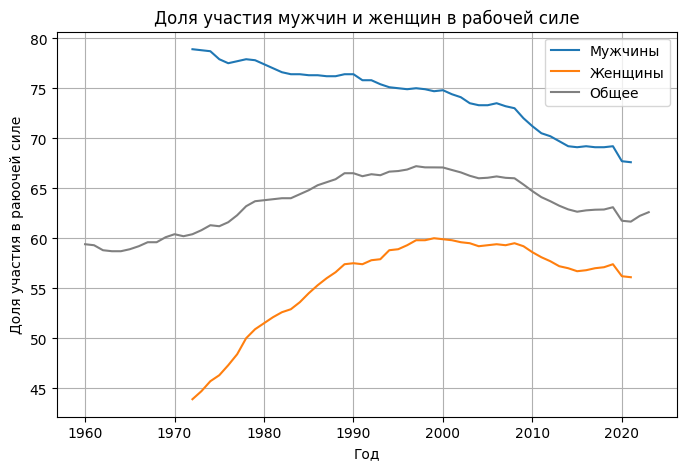

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(df_US['Year'], df_US['Total, male'], label='Мужчины')
plt.plot(df_US['Year'], df_US['Total, female'], label='Женщины')
plt.plot(df_labour_US['Year'], df_labour_US['Value'], color='gray', label='Общее')
plt.title('Доля участия мужчин и женщин в рабочей силе')
plt.xlabel('Год')
plt.ylabel('Доля участия в раюочей силе')
plt.grid(True)
plt.legend()
plt.show()


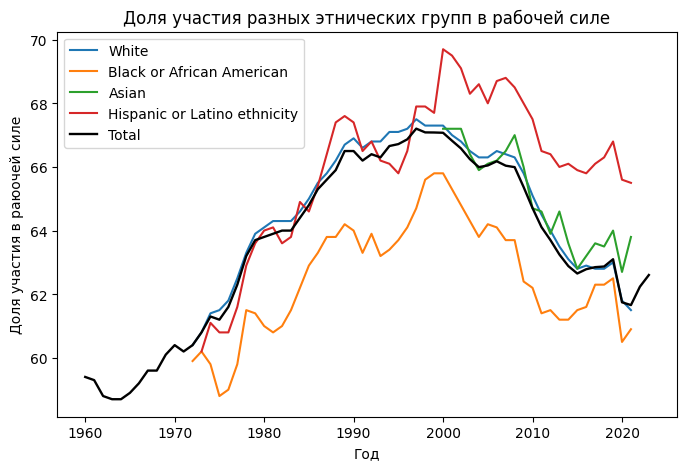

In [44]:
df_US['Hispanic or Latino ethnicity, total'] = pd.to_numeric(df_US['Hispanic or Latino ethnicity, total'], errors='coerce')
df_US['Asian, total'] = pd.to_numeric(df_US['Asian, total'], errors = 'coerce')
plt.figure(figsize=(8, 5))
plt.plot(df_US['Year'], df_US['White, total'], label='White')
plt.plot(df_US['Year'], df_US['Black or African American, total'], label='Black or African American')
plt.plot(df_US['Year'], df_US['Asian, total'], label='Asian')
plt.plot(df_US['Year'], df_US['Hispanic or Latino ethnicity, total'], label='Hispanic or Latino ethnicity')
plt.plot(df_labour_US['Year'], df_labour_US['Value'], label='Total', linewidth=1.7, color='black')
plt.title('Доля участия разных этнических групп в рабочей силе')

plt.xlabel('Год')
plt.ylabel('Доля участия в раюочей силе')
plt.legend()
plt.show()

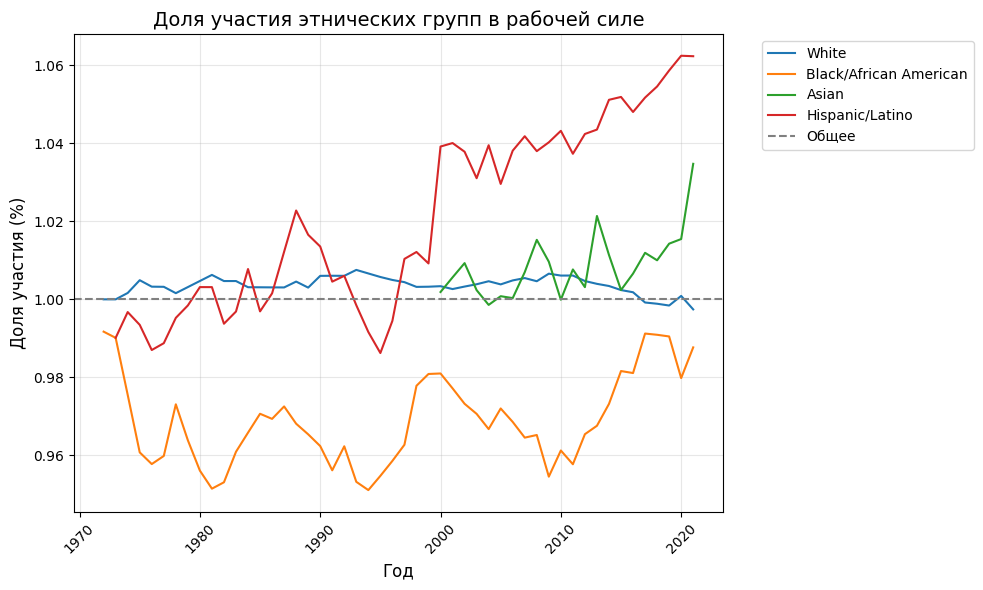

In [45]:
# Преобразование данных в числовой формат
df_US = df_US.copy()
df_US['Hispanic or Latino ethnicity, total'] = pd.to_numeric(df_US['Hispanic or Latino ethnicity, total'], errors='coerce')
df_US['Asian, total'] = pd.to_numeric(df_US['Asian, total'], errors='coerce')
df_US['White, total'] = pd.to_numeric(df_US['White, total'], errors='coerce')
df_US['Black or African American, total'] = pd.to_numeric(df_US['Black or African American, total'], errors='coerce')

# Синхронизация данных по годам
common_years = set(df_US['Year']).intersection(set(df_labour_US['Year']))
df_US_sync = df_US[df_US['Year'].isin(common_years)].sort_values('Year')
df_labour_sync = df_labour_US[df_labour_US['Year'].isin(common_years)].sort_values('Year')

# Вычисление долей
df_US_sync['White Share'] = df_US_sync['White, total'] / df_labour_sync['Value'].values
df_US_sync['Black or African American Share'] = df_US_sync['Black or African American, total'] / df_labour_sync['Value'].values
df_US_sync['Asian Share'] = df_US_sync['Asian, total'] / df_labour_sync['Value'].values
df_US_sync['Hispanic or Latino Share'] = df_US_sync['Hispanic or Latino ethnicity, total'] / df_labour_sync['Value'].values

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(df_US_sync['Year'], df_US_sync['White Share'], label='White')
plt.plot(df_US_sync['Year'], df_US_sync['Black or African American Share'], label='Black/African American')
plt.plot(df_US_sync['Year'], df_US_sync['Asian Share'], label='Asian')
plt.plot(df_US_sync['Year'], df_US_sync['Hispanic or Latino Share'], label='Hispanic/Latino')
plt.axhline(y=1, label='Общее', linestyle='--', color='gray')

# Настройки графика
plt.title('Доля участия этнических групп в рабочей силе', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля участия (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Легенда справа
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


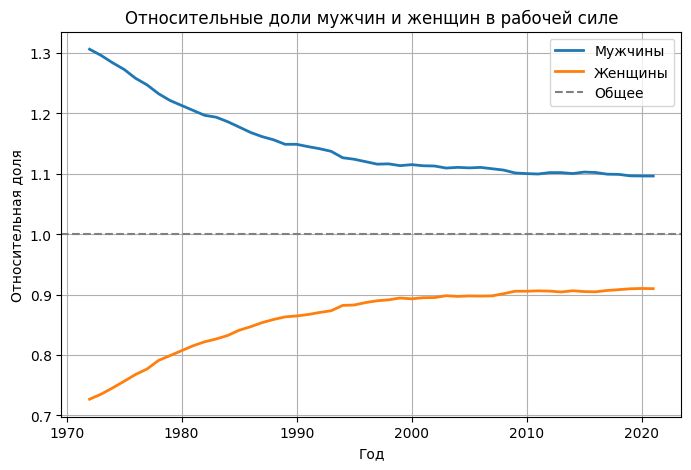

In [46]:
df_labour_US = df_labour_US.copy()
df_labour_US['Value'] = pd.to_numeric(df_labour_US['Value'], errors='coerce')

df_US_sync = df_US[df_US['Year'].isin(common_years)].sort_values('Year')
df_labour_US_sync = df_labour_US[df_labour_US['Year'].isin(common_years)].sort_values('Year')

# Вычисление долей
df_US_sync['Male Share'] = df_US_sync['Total, male'] / df_labour_US_sync['Value'].values
df_US_sync['Female Share'] = df_US_sync['Total, female'] / df_labour_US_sync['Value'].values

plt.figure(figsize=(8, 5))
plt.plot(df_US_sync['Year'], df_US_sync['Male Share'], label='Мужчины', linewidth=2)
plt.plot(df_US_sync['Year'], df_US_sync['Female Share'], label='Женщины', linewidth=2)
plt.axhline(y=1, label='Общее', linestyle='--', color='gray')
plt.title('Относительные доли мужчин и женщин в рабочей силе')
plt.xlabel('Год')
plt.ylabel('Относительная доля')
plt.grid(True)
plt.legend()
plt.show()


## let's check if countries match in one and the other table(it's the same number of them and every is represented in both data frames)

In [14]:
set1 = set(df_population['Country Code'])
set2 = set(df_labour['Country Code'])

diff_population = set1 - set2
diff_labour = set2 - set1

diff_population # it shows countries that have data about population, but no about labour force participation


{'MAF', 'SXM'}

## Let's analyse some data from EU

In [122]:
df_EU_workers = df_EU[(df_EU['citizen'] == 'FOR') & (df_EU['wstatus']=='EMP') & (df_EU['geo\TIME_PERIOD']=='EU27_2020') & (df_EU['sex']=='T') & (df_EU['age']=='Y15-59')]
df_EU_workers

,freq,unit,sex,citizen,age,wstatus,geo\TIME_PERIOD,1995,1996,1997,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
88000,A,THS_PER,T,FOR,Y15-59,EMP,EU27_2020,NaN,NaN,NaN,...,11755.4,12235.7,12911.8,13582.2,14254.9,14995.3,14477.7,14927.7,16449.9,17787.1


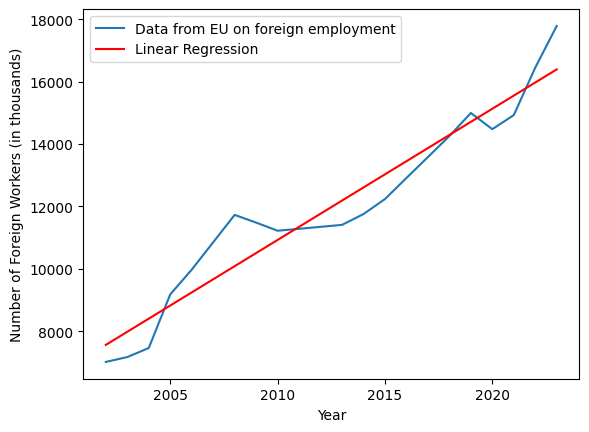

In [176]:
#this graph shows number of foreigners who work in EU(in thousands) 
x = df_EU_workers.columns[14:]
x = np.array(x).astype(float).reshape(-1, 1)
y = df_EU_workers.iloc[0, 14:].values.astype(float)

plt.plot(x,y,label='Data from EU on foreign employment')

model_regression = LinearRegression()
model_regression.fit(x, y)

# Predicting values
y_pred = model_regression.predict(x)

# Plotting the linear regression line
plt.plot(x, y_pred, color='red', label='Linear Regression')

# Adding labels and legend
plt.xlabel('Year')
plt.ylabel('Number of Foreign Workers (in thousands)')
plt.legend()


* Как можно заметить тенденция трудоустройства иностранцев в ЕС идёт вверх, так что в будущем можно ожидать рост этой метрики

## real work starts here

Теперь, когда данные собраны, давайте рассмотрим их подробнее.

Начнём с таблицы `df_labour`. Эта таблица содержит различные показатели, отражающие уровень участия населения конкретной страны в рабочей силе. В ней представлены как общие данные по населению, так и детализированные сведения с разбивкой по возрасту и полу.

Рассмотрим их более внимательно.

In [ ]:
df_labour.head()

,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation
0,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2023,64.487,"female, Modeled, 15+"
1,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2022,64.218,"female, Modeled, 15+"
2,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2021,64.059,"female, Modeled, 15+"
3,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2020,63.535,"female, Modeled, 15+"
4,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2019,64.309,"female, Modeled, 15+"


In [ ]:
df_labour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98841 entries, 0 to 98840
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Indicator Name  98841 non-null  object 
 1   Indicator Code  98841 non-null  object 
 2   Country Name    98841 non-null  object 
 3   Country Code    98841 non-null  object 
 4   Year            98841 non-null  int64  
 5   Value           98841 non-null  float64
 6   Disaggregation  98841 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 5.3+ MB


Проверим данные на пропуски

In [ ]:
df_labour.isnull().sum()

Indicator Name    0
Indicator Code    0
Country Name      0
Country Code      0
Year              0
Value             0
Disaggregation    0
dtype: int64

Убедились что пропусков в данной таблице нет, можем начинать работать с ней. 

Так как у нас в основном категориальные признаки можно погруппировать данные и посмотреть на них

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
df_labour['Indicator Name'].unique() # посмотрим какие у нас есть показатели

array(['Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)',
       'Labor force participation rate, female (% of female population ages 15+) (national estimate)',
       'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)',
       'Labor force participation rate, male (% of male population ages 15+) (national estimate)',
       'Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)',
       'Labor force participation rate, total (% of total population ages 15+) (national estimate)',
       'Labor force participation rate for ages 15-24, female (%) (modeled ILO estimate)',
       'Labor force participation rate for ages 15-24, female (%) (national estimate)',
       'Labor force participation rate for ages 15-24, male (%) (modeled ILO estimate)',
       'Labor force participation rate for ages 15-24, male (%) (national estimate)',
       'Labor force participati

In [ ]:
# для каких годов у нас есть данные
df_labour['Year'].unique()

array([2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013,
       2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002,
       2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992, 1991,
       1980, 1960, 1961, 1990, 1982, 1989, 1988, 1987, 1986, 1985, 1984,
       1983, 1981, 1970, 1979, 1978, 1977, 1976, 1975, 1974, 1973, 1972,
       1971, 1969, 1968, 1967, 1966, 1965, 1964, 1963, 1962])

In [ ]:
# и на страны
df_labour['Country Name'].unique()

array(['Africa Eastern and Southern', 'Africa Western and Central',
       'Arab World', 'Caribbean small states',
       'Central Europe and the Baltics', 'Early-demographic dividend',
       'East Asia & Pacific',
       'East Asia & Pacific (excluding high income)',
       'East Asia & Pacific (IDA & IBRD)', 'Euro area',
       'Europe & Central Asia',
       'Europe & Central Asia (excluding high income)',
       'Europe & Central Asia (IDA & IBRD)', 'European Union',
       'Fragile and conflict affected situations',
       'Heavily indebted poor countries (HIPC)', 'High income',
       'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only',
       'IDA total', 'Late-demographic dividend',
       'Latin America & Caribbean',
       'Latin America & Caribbean (excluding high income)',
       'Latin America & Caribbean (IDA & IBRD)',
       'Least developed countries: UN classification',
       'Low & middle income', 'Low income', 'Lower middle income',
       'Middle East & North

Для начала давайте посмотрим на само распределение уровня занятости населения по миру за 2023 год.
Думаю еще важно указать что это оценка Международной организации труда (International labour organization)

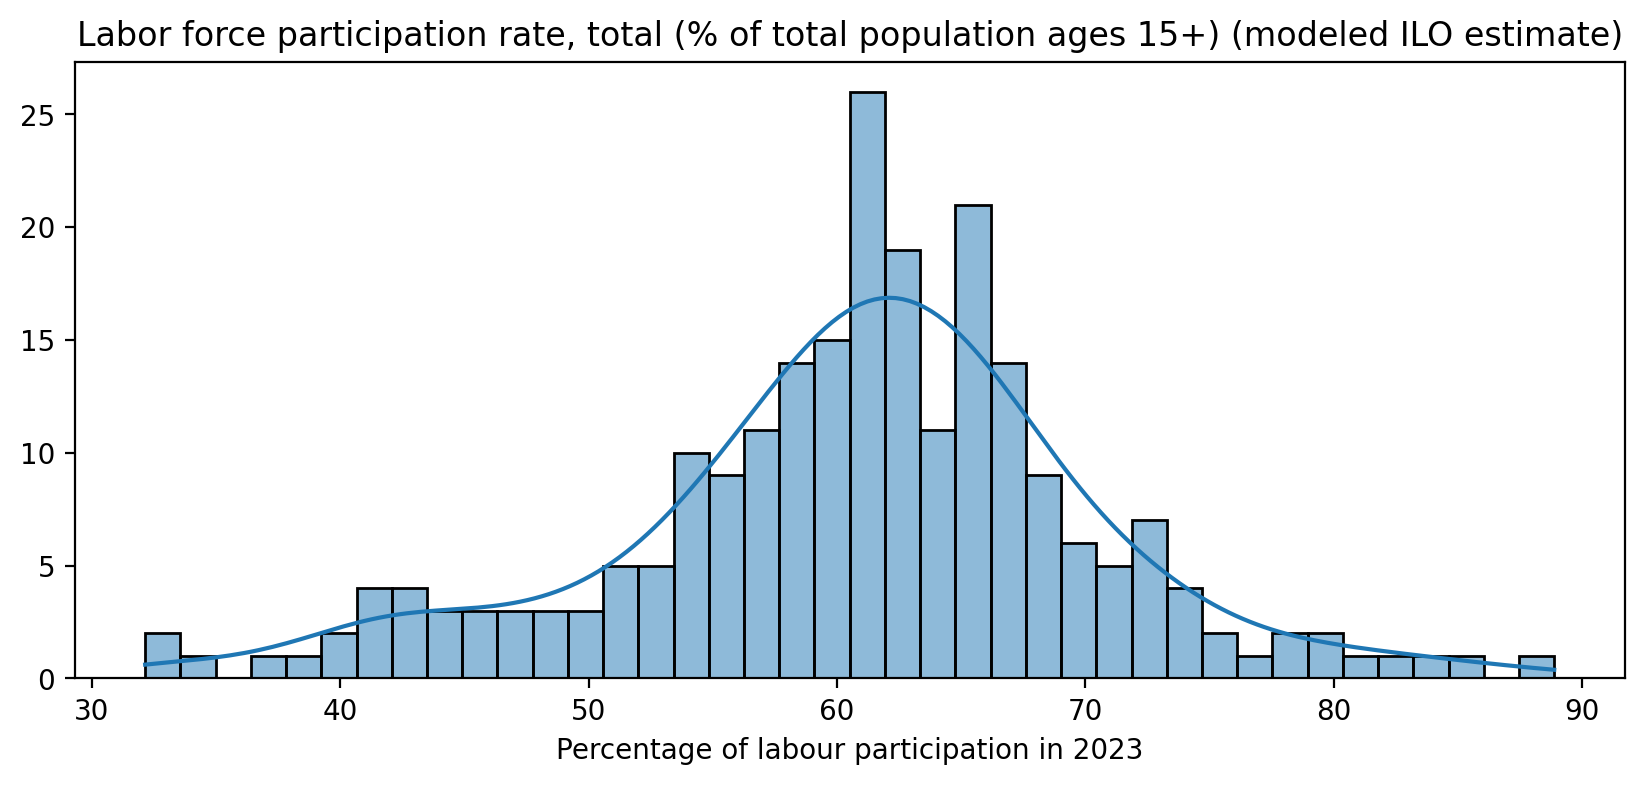

In [ ]:
plt.figure(figsize=(10, 4), dpi=200)
# создадим нужный нам датафрейм
df_labour2023=df_labour[(df_labour['Year']==2023) & (df_labour['Indicator Name']=='Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)')]

sns.histplot(data=df_labour2023, x='Value', bins=40, kde=True)
plt.title('Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)')
plt.xlabel('Percentage of labour participation in 2023')
plt.ylabel('');

Заметим, что у нас почти для каждого показателя есть оценка Международной организации труда и оценка, посчитанная внутри страны. Можно сравнить распределения уровня занятости по миру в зависимости от источника данных

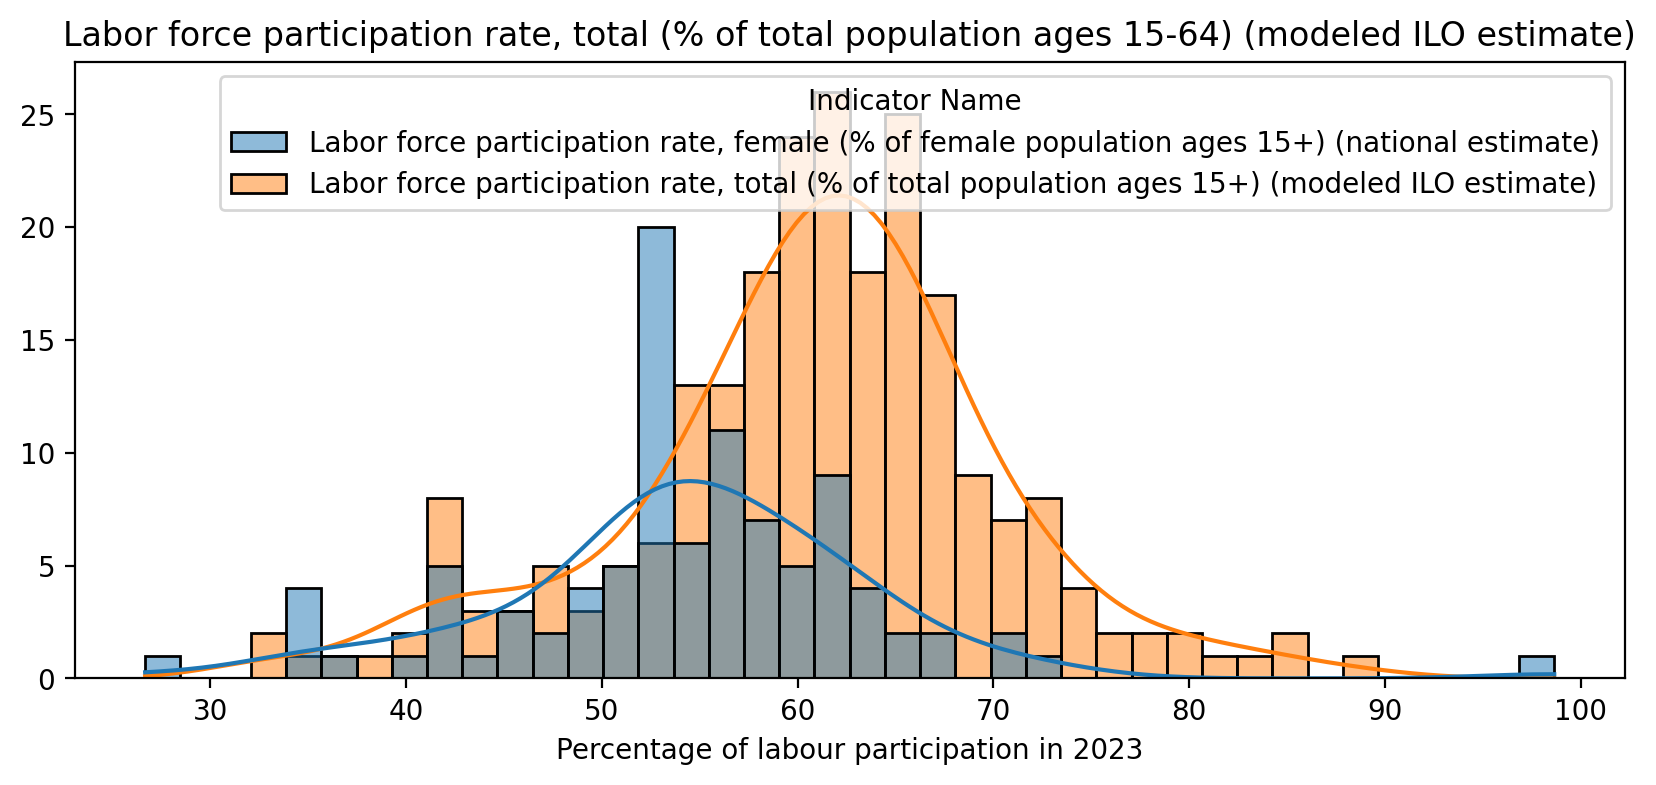

In [ ]:
plt.figure(figsize=(10, 4), dpi=200)
# создадим нужный нам датафрейм
df_labour2023=df_labour[(df_labour['Year']==2023) & (df_labour['Indicator Name'].isin(['Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)', 'Labor force participation rate, female (% of female population ages 15+) (national estimate)']))]

ax=sns.histplot(data=df_labour2023, x='Value', bins=40, hue='Indicator Name', kde=True)
plt.title('Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)')
plt.xlabel('Percentage of labour participation in 2023')
plt.ylabel('');

Можем посмотреть как менялся этот показатель во времени. Возьмем оценку ILO

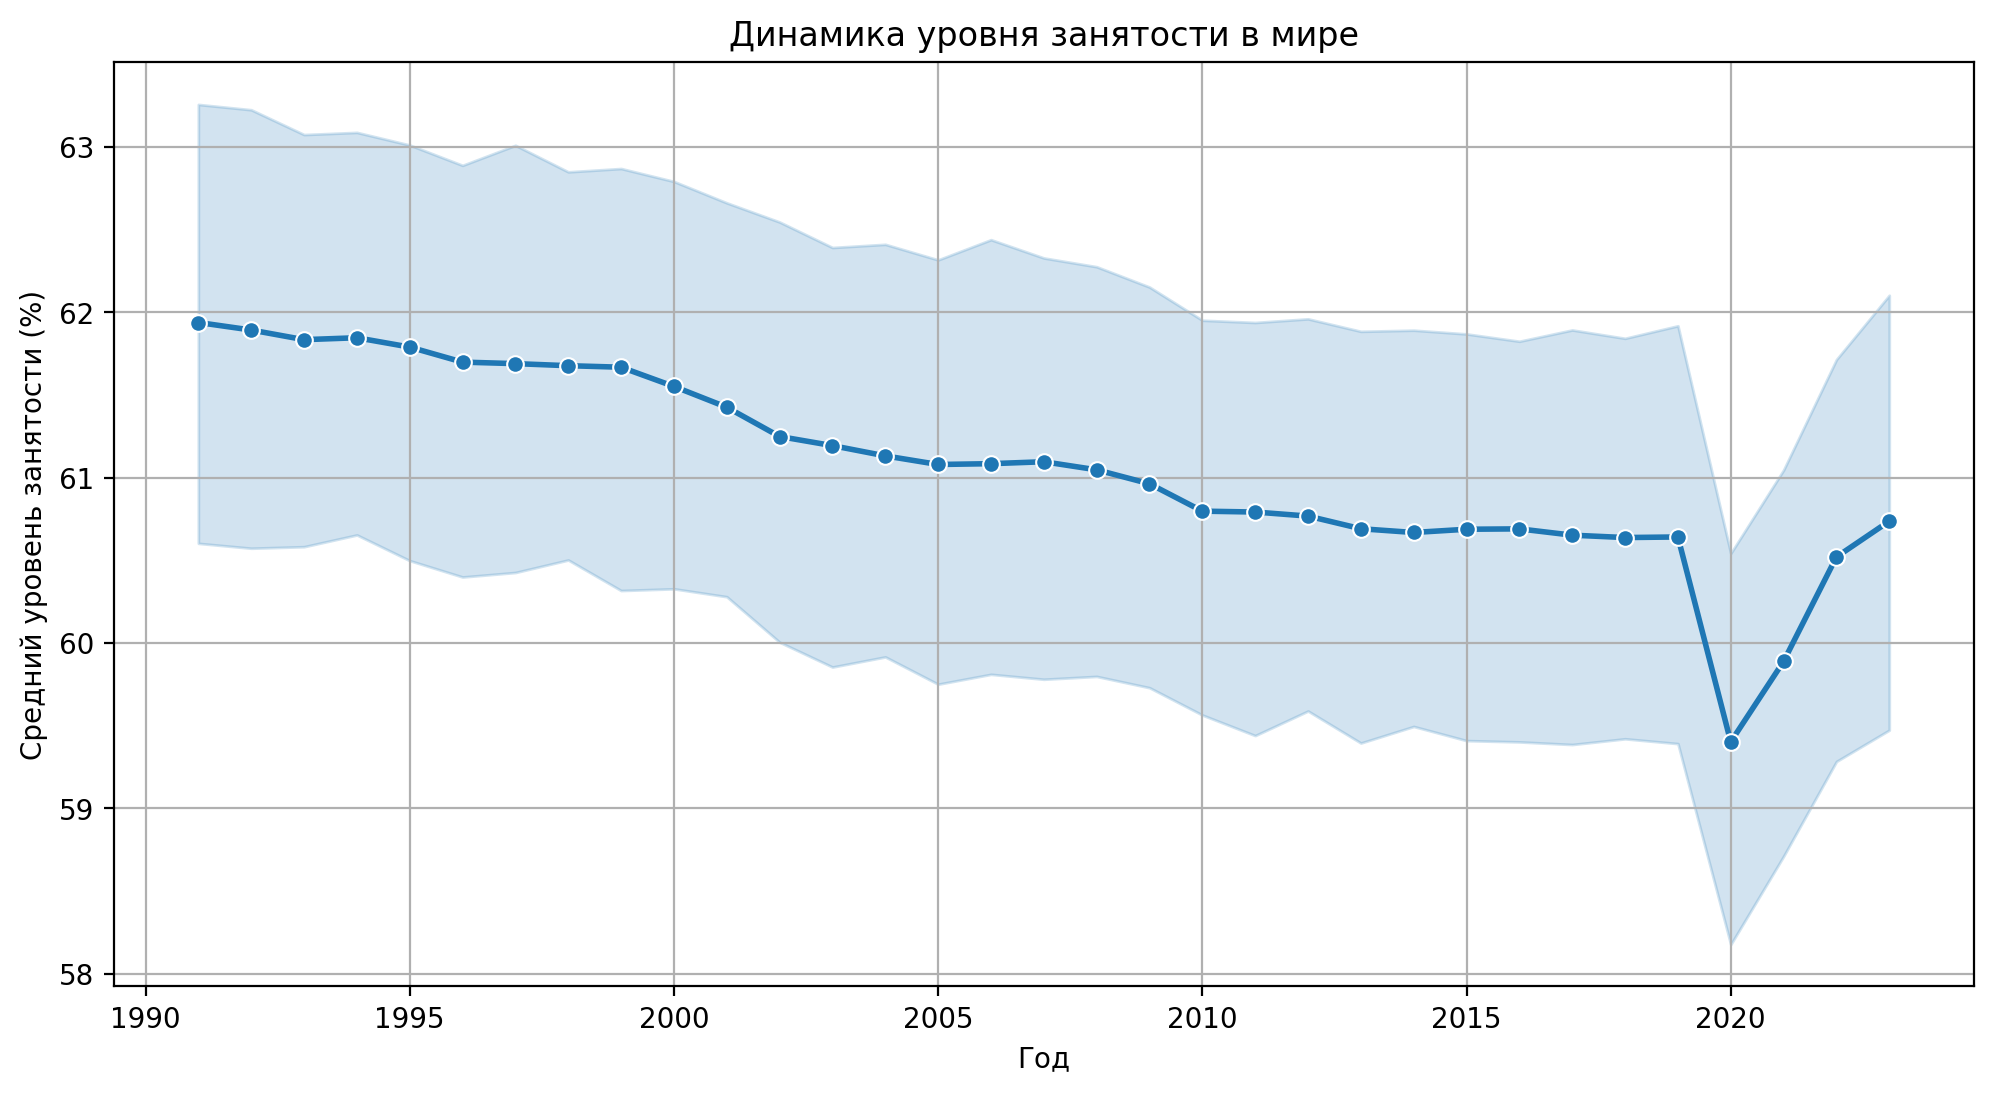

In [ ]:
df_labour_total=df_labour[df_labour['Indicator Name']=='Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)']
df_labour_total.groupby('Year')['Value'].mean()

plt.figure(figsize=(12, 6), dpi=200)

sns.lineplot(data=df_labour_total, x="Year", y="Value", marker="o", linewidth=2)

plt.title("Динамика уровня занятости в мире")
plt.xlabel("Год")
plt.ylabel("Средний уровень занятости (%)")
plt.grid(True)
plt.show()

Можем рассмотреть схожую динамику для женщин

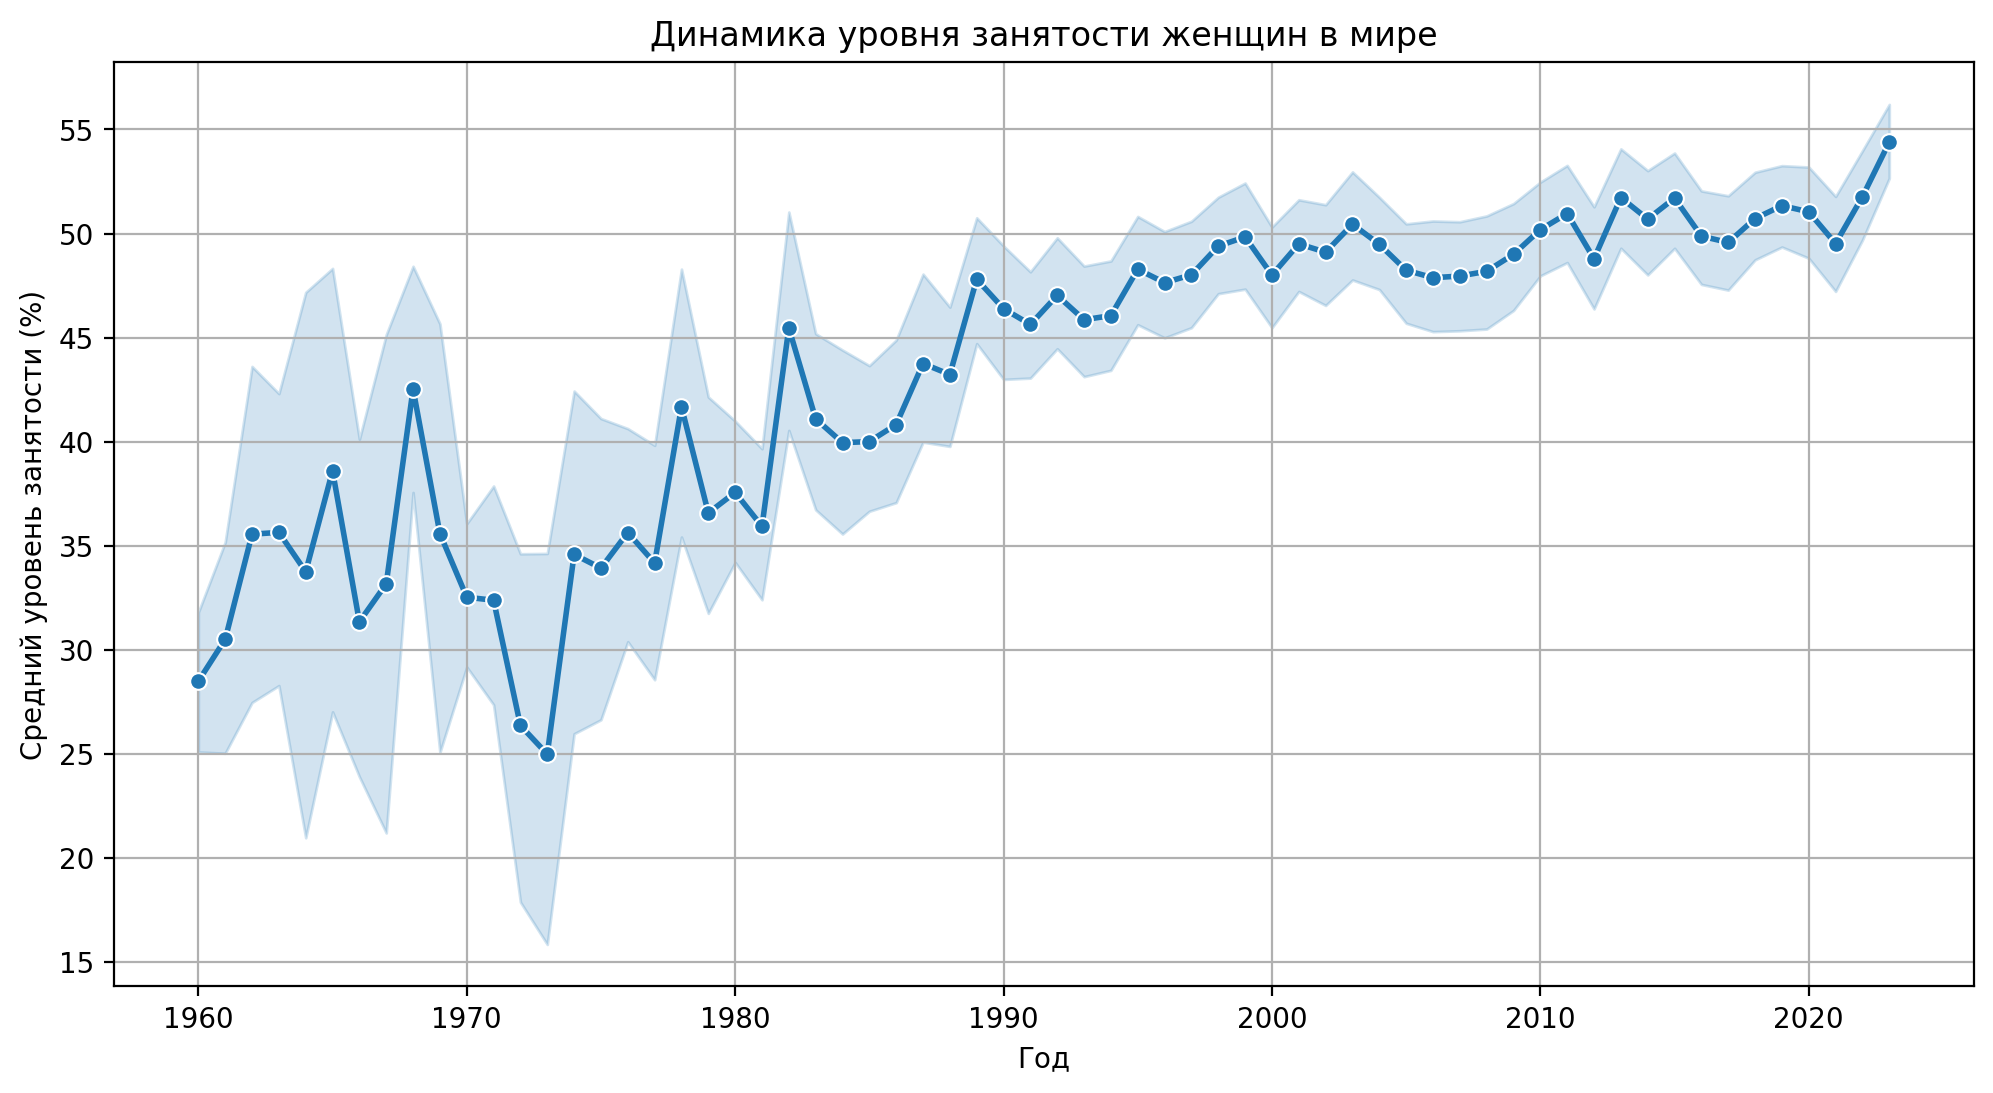

In [ ]:
df_labour_female=df_labour[df_labour['Indicator Name']=='Labor force participation rate, female (% of female population ages 15+) (national estimate)']
df_labour_female.groupby('Year')['Value'].mean()

plt.figure(figsize=(12, 6), dpi=200)

sns.lineplot(data=df_labour_female, x="Year", y="Value", marker="o", linewidth=2)

plt.title("Динамика уровня занятости женщин в мире")
plt.xlabel("Год")
plt.ylabel("Средний уровень занятости (%)")
plt.grid(True)
plt.show()

Посмотрим на страны с наибольшим и наименьшим уровнем занятости за 2023 год

/var/folders/7z/02b8fxy15nvgyqr1w6c1n6bm0000gn/T/ipykernel_31080/3805541895.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, y="Country Name", x="Value", palette="Blues_r")
/var/folders/7z/02b8fxy15nvgyqr1w6c1n6bm0000gn/T/ipykernel_31080/3805541895.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_countries, y="Country Name", x="Value", palette="Reds_r")


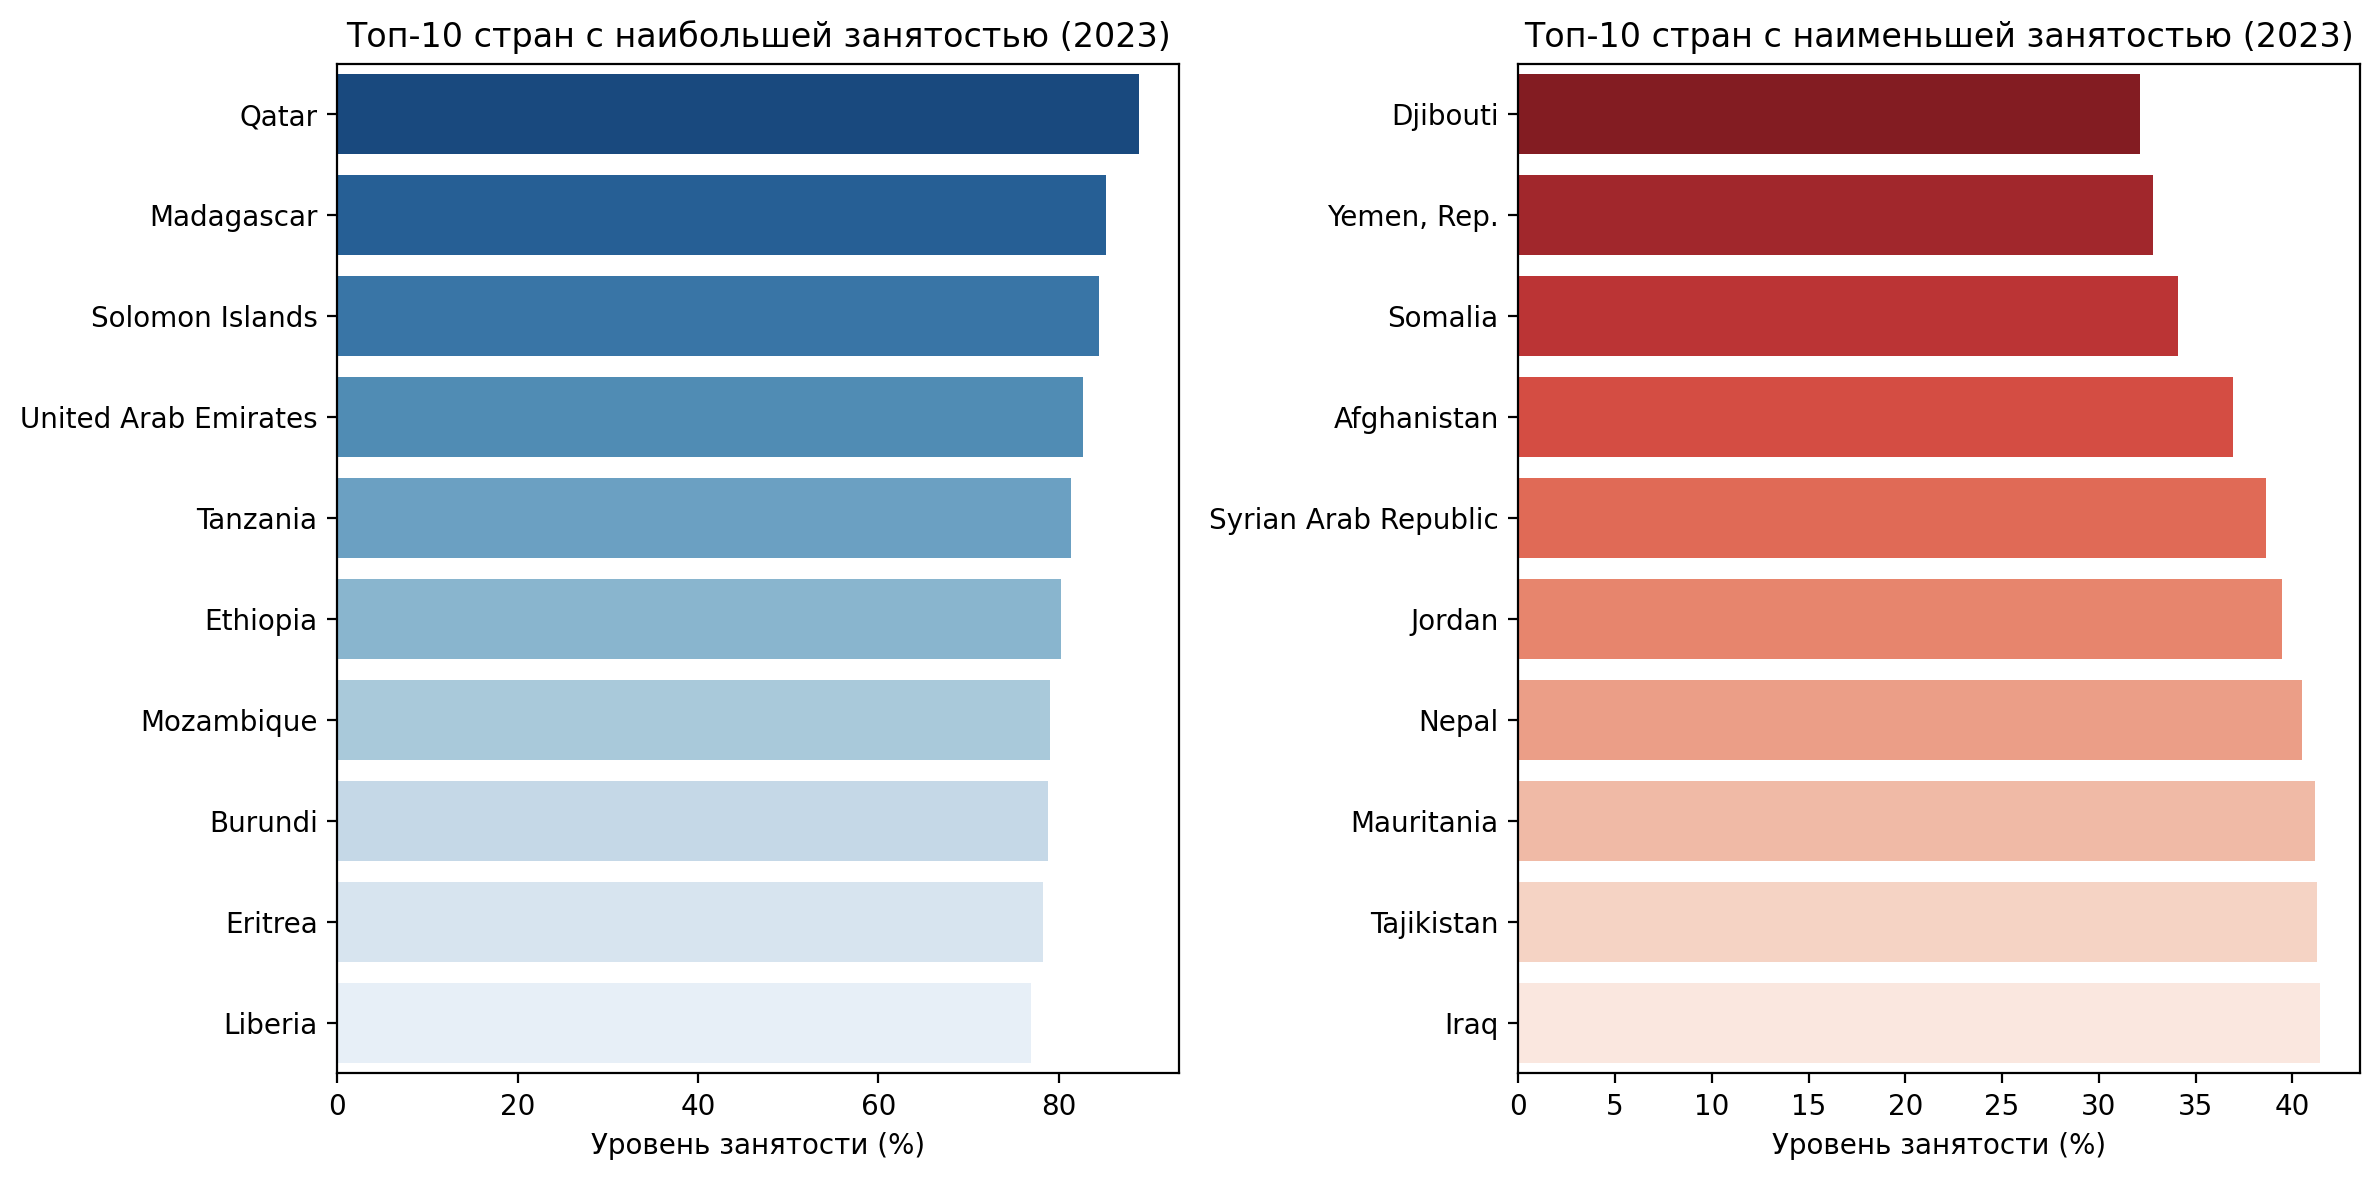

In [ ]:
df_latest = df_labour[(df_labour["Year"] == 2023) & 
                      (df_labour["Indicator Name"] == 
                       "Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)")]
top_countries = df_latest.nlargest(10, "Value")  # 10 стран с наибольшей занятостью
bottom_countries = df_latest.nsmallest(10, "Value")  # 10 стран с наименьшей занятостью

plt.figure(figsize=(12, 6), dpi=200)

# Топ-10 стран с высокой занятостью
plt.subplot(1, 2, 1)
sns.barplot(data=top_countries, y="Country Name", x="Value", palette="Blues_r")
plt.xlabel("Уровень занятости (%)")
plt.ylabel("")
plt.title(f"Топ-10 стран с наибольшей занятостью (2023)")

# Топ-10 стран с низкой занятостью
plt.subplot(1, 2, 2)
sns.barplot(data=bottom_countries, y="Country Name", x="Value", palette="Reds_r")
plt.xlabel("Уровень занятости (%)")
plt.ylabel("")
plt.title(f"Топ-10 стран с наименьшей занятостью (2023)")

plt.tight_layout();



На основе имеющихся данных можно рассчитать новые переменные:
- темп изменения занятости
- разрыв в занятости между мужчинами и женщинами

Введем переменную темп изменения занятости 

In [ ]:
df_labour["Change Rate"] = df_labour.groupby(["Country Name", "Indicator Name"])["Value"].pct_change() * 100

Посмотрим на гендерный разрыв между мужчинами и женщинами

In [ ]:
# Создаем сводную таблицу, где значения - это процент занятости
df_pivot = df_labour.pivot_table(index=["Country Name", "Year"], 
                                 columns="Indicator Name", 
                                 values="Value").reset_index()

# Добавляем колонку с разрывом между мужской и женской занятостью
df_pivot["Gender Gap"] = df_pivot["Labor force participation rate, male (% of male population ages 15+) (national estimate)"] - \
                         df_pivot["Labor force participation rate, female (% of female population ages 15+) (national estimate)"]

# Оставляем только нужные столбцы
df_gender_gap = df_pivot[["Country Name", "Year", "Gender Gap"]]

# Объединяем с исходным датафреймом (через merge)
df_labour = df_labour.merge(df_gender_gap, on=["Country Name", "Year"], how="left")

# Проверяем результат
df_labour.head()


,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation,Change Rate,Gender Gap
0,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2023,64.487,"female, Modeled, 15+",NaN,NaN
1,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2022,64.218,"female, Modeled, 15+",-0.417138,NaN
2,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2021,64.059,"female, Modeled, 15+",-0.247594,NaN
3,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2020,63.535,"female, Modeled, 15+",-0.817996,NaN
4,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,Africa Eastern and Southern,AFE,2019,64.309,"female, Modeled, 15+",1.218226,NaN


In [ ]:
df_labour['Gender Gap'].isnull().sum()

34734

Хммм... у нас слишком много пропусков. Не думаю что на основе этой переменной получится рассчитать что-либо. Поэтому она бесполезна

Думаю мы можем перейти ко второй таблице. Она как раз отражает соотношение женщин и мужчин в уровне занятости по разным странам. Посмотрим на них подробнее

In [ ]:
df_f2mratio.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1990,1991,1992,1993,1994,1995,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,84.643246,84.814834,84.952709,85.097814,85.447582,85.695731,...,85.666985,85.303943,84.9756999123733,84.636705,84.224640,83.843562,83.224101,83.484320,83.462266,86.178096
1,Afghanistan,AFG,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,19.716287,19.657308,19.554468,19.418106,19.241972,19.041307,...,23.754362,25.379774,27.1056064334799,28.936935,27.751625,26.375400,24.678652,21.795863,7.346387,7.339854
2,Africa Western and Central,AFW,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,84.593159,84.533613,84.484334,84.322679,84.193564,84.113843,...,85.868717,85.692845,85.2865400782277,85.112944,84.947476,84.856368,84.327709,84.850259,84.750611,87.753791
3,Angola,AGO,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,95.685684,95.469820,95.271727,95.093755,94.940577,94.867090,...,94.004842,94.113828,94.2285071344551,94.345269,94.467953,94.594069,94.673470,95.603481,93.617593,93.402725
4,Albania,ALB,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,69.927935,70.992569,71.266915,70.881961,70.571002,70.147181,...,69.436239,73.324307,76.6623127160968,74.509745,76.119049,77.833657,77.560527,78.421800,78.225249,78.264003


In [ ]:
df_f2mratio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    235 non-null    object 
 1   Country Code    235 non-null    object 
 2   Indicator Name  235 non-null    object 
 3   Indicator Code  235 non-null    object 
 4   1990            235 non-null    float64
 5   1991            235 non-null    float64
 6   1992            235 non-null    float64
 7   1993            235 non-null    float64
 8   1994            235 non-null    float64
 9   1995            235 non-null    float64
 10  1996            235 non-null    float64
 11  1997            235 non-null    float64
 12  1998            235 non-null    float64
 13  1999            235 non-null    float64
 14  2000            235 non-null    float64
 15  2001            235 non-null    float64
 16  2002            235 non-null    float64
 17  2003            235 non-null    flo

Мы видим что у нас в двух колонках есть пропуски. Посмотрим на них подробнее

In [ ]:
df_f2mratio[(df_f2mratio['2022'].isnull()) | (df_f2mratio['2023'].isnull())]

,Country Name,Country Code,Indicator Name,Indicator Code,1990,1991,1992,1993,1994,1995,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
172,West Bank and Gaza,PSE,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,17.143020,17.199515,17.364847,17.411795,17.467009,17.584617,...,24.191570,25.421263,24.5487313790093,24.776639,25.164535,25.839506,24.747718,24.987538,26.262206,NaN
182,Sudan,SDN,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,30.666389,31.853244,33.084007,34.374548,35.723342,37.120238,...,36.206032,34.933413,33.5869977975241,32.312180,30.973701,29.410554,27.500764,25.540269,23.440389,NaN
219,Ukraine,UKR,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,80.230956,80.657369,81.093183,81.537004,81.990215,82.453993,...,80.415350,79.506165,78.6109017834715,77.729551,76.857862,76.001483,75.885462,75.981219,NaN,NaN


Избавляться от колонок за 2022 и 2023 год не хочется и бессмысленно, ровно также как и удаление строк. В целом можно заполнить эти строки средним по каждой стране

In [ ]:
row_means=df_f2mratio.mean(numeric_only=True, axis=1)

In [ ]:
indexes = df_f2mratio[(df_f2mratio['2022'].isnull()) | (df_f2mratio['2023'].isnull())].index
for index in indexes:
    df_f2mratio.loc[index]=df_f2mratio.loc[index].fillna(row_means[index])

Теперь когда пропусков нет можно работать дальше

In [ ]:
# для удобства сделаем индексом название страны
df_f2mratio.set_index('Country Name', inplace=True)

In [ ]:
df_f2mratio

,Country Code,Indicator Name,Indicator Code,1990,1991,1992,1993,1994,1995,1996,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Country Name,,,,,,,,,,,,,,,,,,,,,
Africa Eastern and Southern,AFE,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,84.643246,84.814834,84.952709,85.097814,85.447582,85.695731,85.594354,...,85.666985,85.303943,84.9756999123733,84.636705,84.224640,83.843562,83.224101,83.484320,83.462266,86.178096
Afghanistan,AFG,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,19.716287,19.657308,19.554468,19.418106,19.241972,19.041307,18.821233,...,23.754362,25.379774,27.1056064334799,28.936935,27.751625,26.375400,24.678652,21.795863,7.346387,7.339854
Africa Western and Central,AFW,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,84.593159,84.533613,84.484334,84.322679,84.193564,84.113843,84.116224,...,85.868717,85.692845,85.2865400782277,85.112944,84.947476,84.856368,84.327709,84.850259,84.750611,87.753791
Angola,AGO,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,95.685684,95.469820,95.271727,95.093755,94.940577,94.867090,94.863448,...,94.004842,94.113828,94.2285071344551,94.345269,94.467953,94.594069,94.673470,95.603481,93.617593,93.402725
Albania,ALB,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,69.927935,70.992569,71.266915,70.881961,70.571002,70.147181,69.884350,...,69.436239,73.324307,76.6623127160968,74.509745,76.119049,77.833657,77.560527,78.421800,78.225249,78.264003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Samoa,WSM,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,63.060467,62.973549,62.829590,62.576572,62.419951,62.106370,61.840625,...,61.124507,61.211156,61.4380928347707,61.452547,60.540159,59.805875,58.949143,58.236856,55.114209,55.720027
"Yemen, Rep.",YEM,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,22.151294,22.357774,22.723393,22.774270,23.072344,24.411626,25.824582,...,8.912051,8.900398,8.7353633945063,8.599781,8.506404,8.425676,8.418072,8.446326,8.219246,8.135934
South Africa,ZAF,Ratio of female to male labor force participat...,SL.TLF.CACT.FM.ZS,67.374116,67.602412,67.552620,67.895547,67.966589,67.634628,67.588608,...,78.111690,78.409126,78.0393593795325,79.307521,79.213294,79.762982,79.457130,79.476542,80.078402,81.971504


Посмотрим как в среднем по миру меняется соотношение

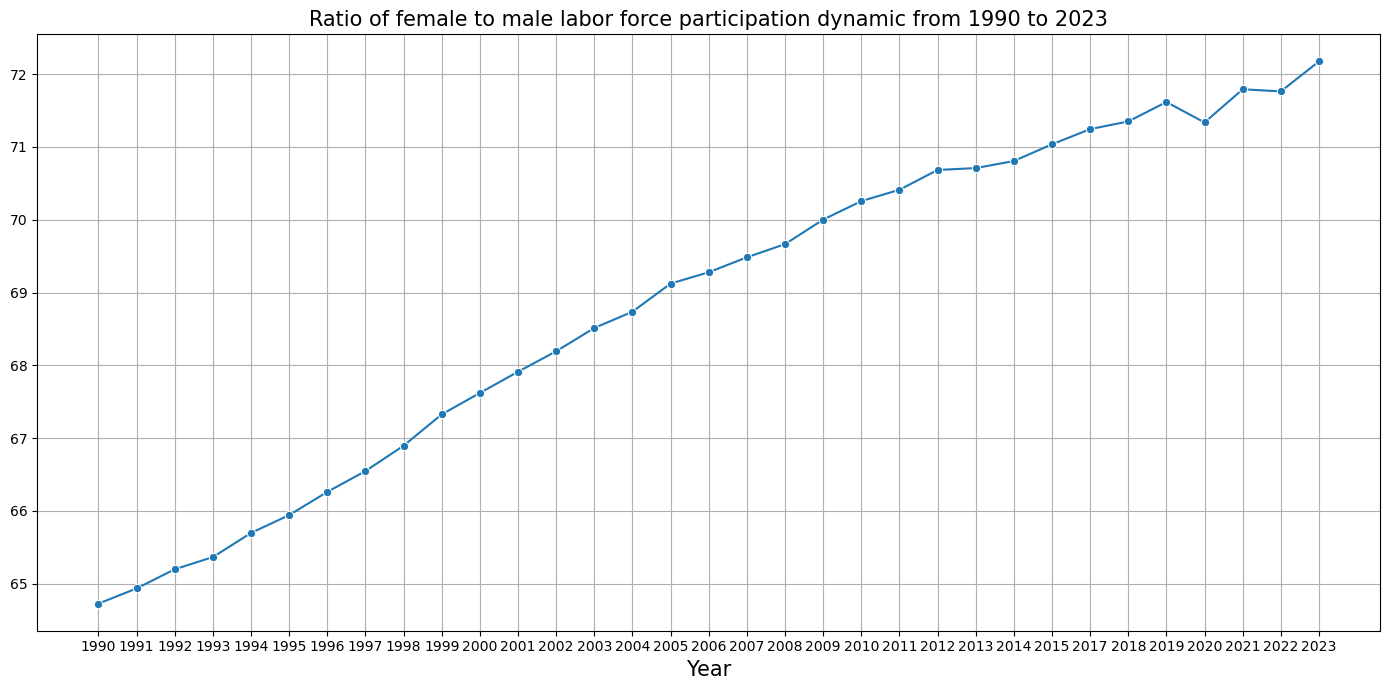

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(df_f2mratio.mean(numeric_only=True), marker='o')
plt.title('Ratio of female to male labor force participation dynamic from 1990 to 2023', fontsize=15)
plt.xlabel('Year', fontsize=15)
plt.grid(True)
plt.tight_layout()

Можно посмотереть на распределение соотношения за последний год

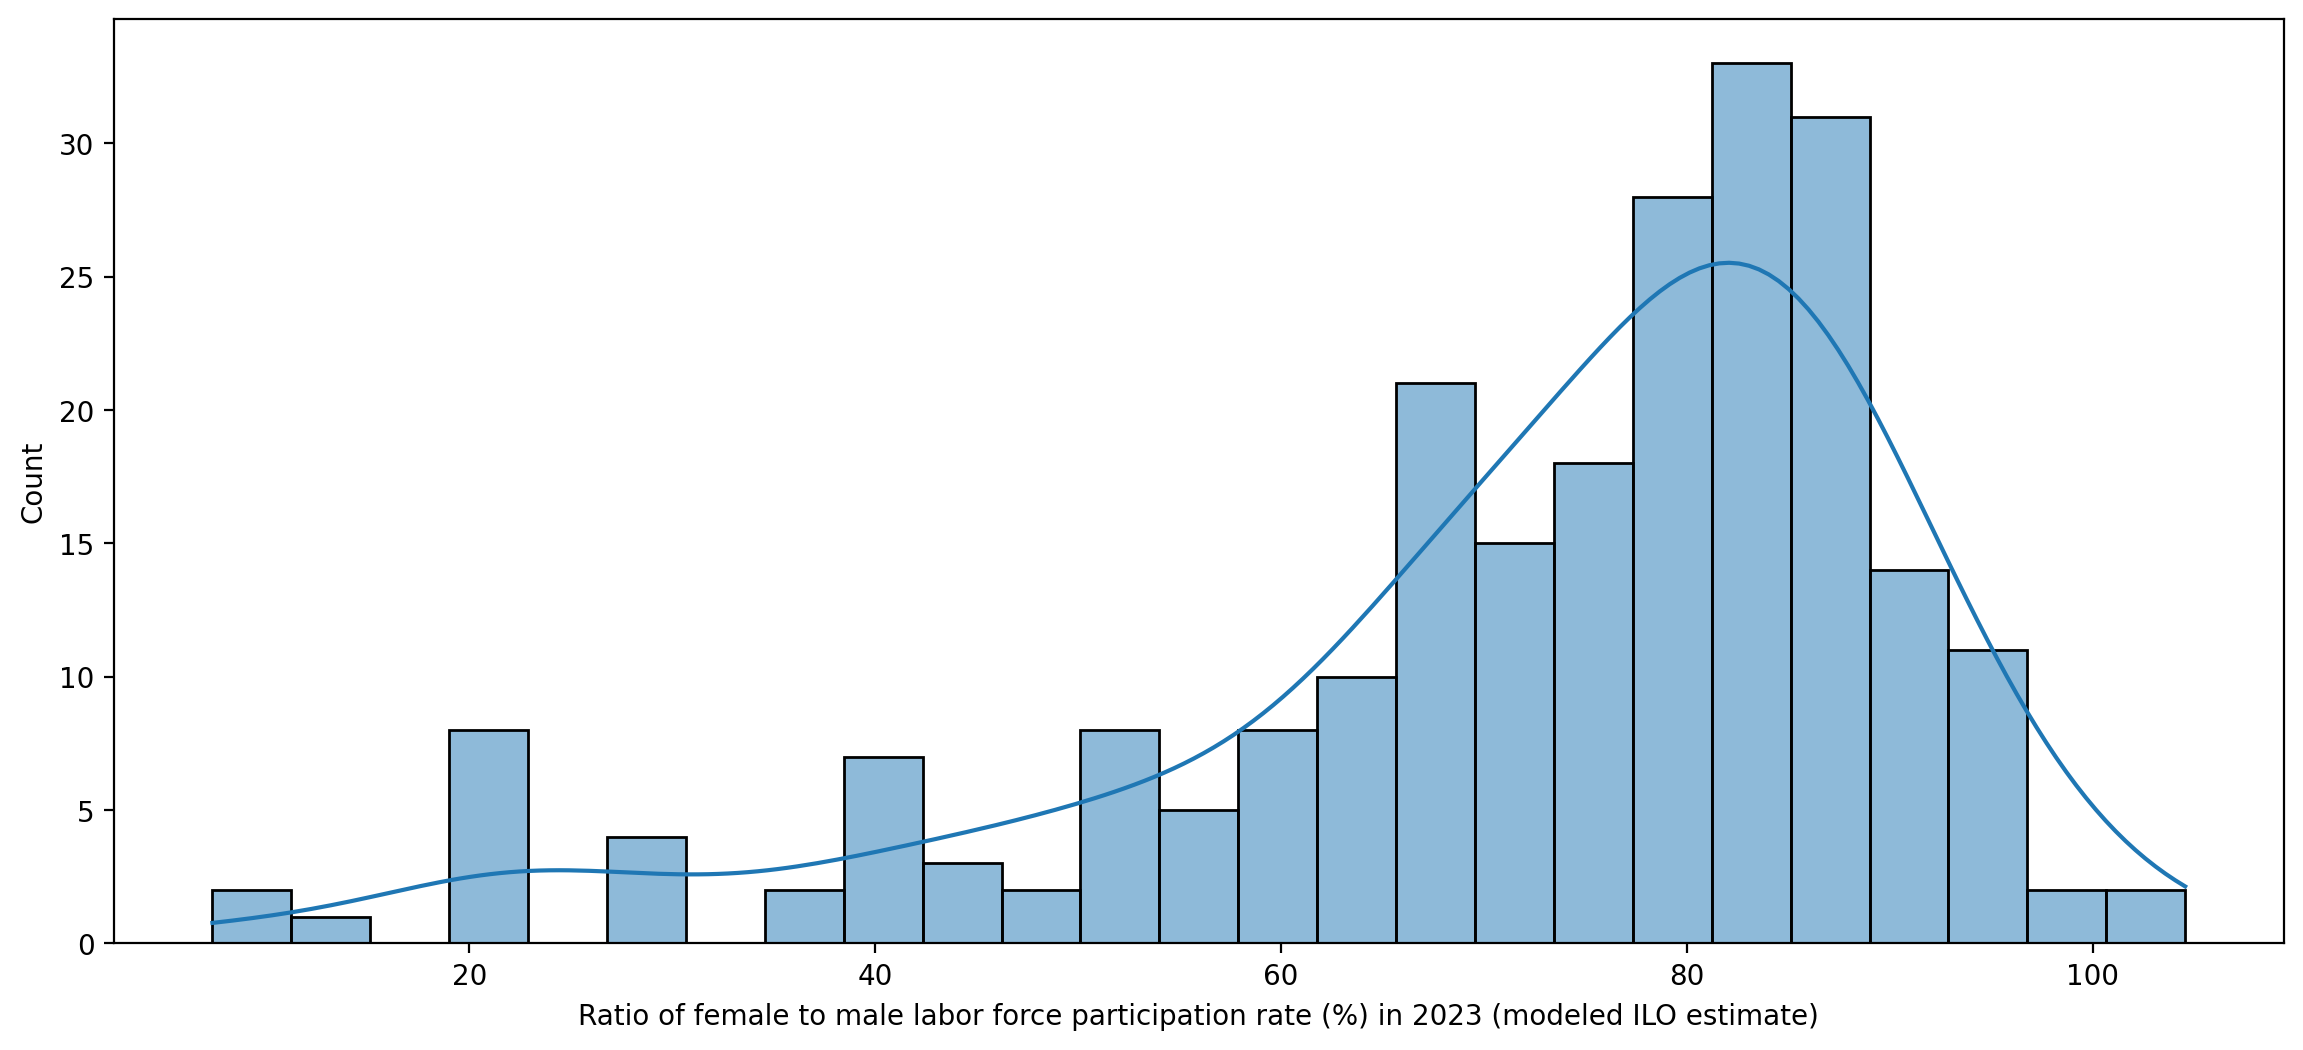

In [ ]:
plt.figure(figsize=(14, 6), dpi=200)
sns.histplot(data=df_f2mratio['2023'], bins=25, kde=True)
plt.xlabel('Ratio of female to male labor force participation rate (%) in 2023 (modeled ILO estimate)');

Посмотрим на ситуацию по всем странам по годам с шагом в 10 лет

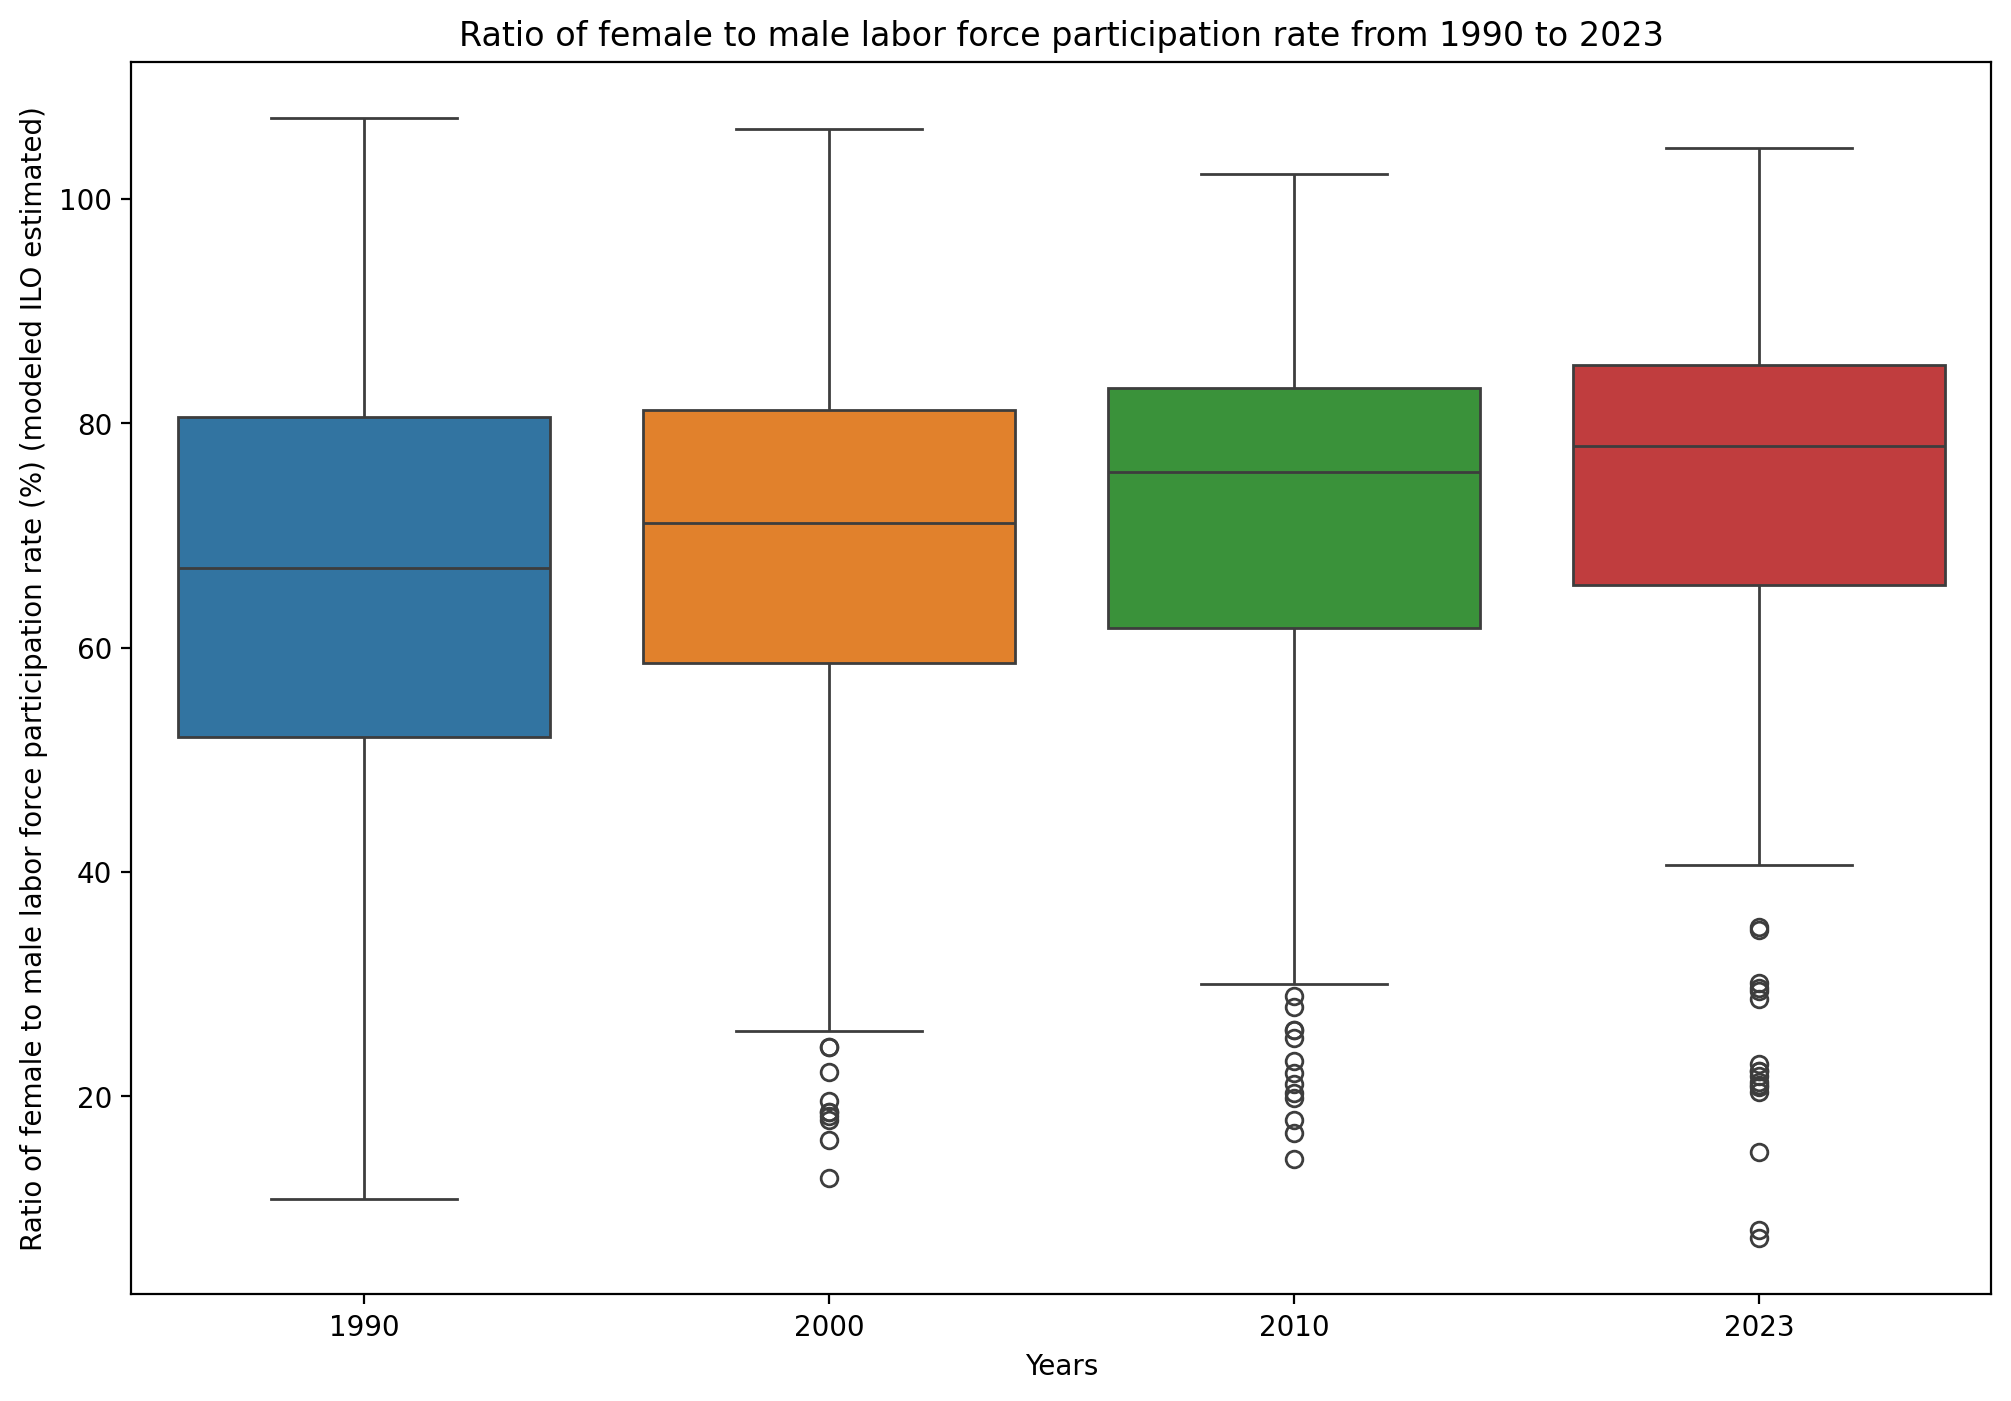

In [ ]:
plt.figure(figsize=(12, 8), dpi=200)
df_f2mratio_fitered = df_f2mratio[['1990', '2000', '2010', '2023']]
sns.boxplot(data=df_f2mratio_fitered)
plt.title('Ratio of female to male labor force participation rate from 1990 to 2023')
plt.xlabel('Years')
plt.ylabel('Ratio of female to male labor force participation rate (%) (modeled ILO estimated)');

Посмотрим на страны с самым высоким и за последний год

/var/folders/7z/02b8fxy15nvgyqr1w6c1n6bm0000gn/T/ipykernel_31080/2040007360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='2023', y=top_10.index, palette='Greens_r')


<Axes: xlabel='2023', ylabel='Country Name'>

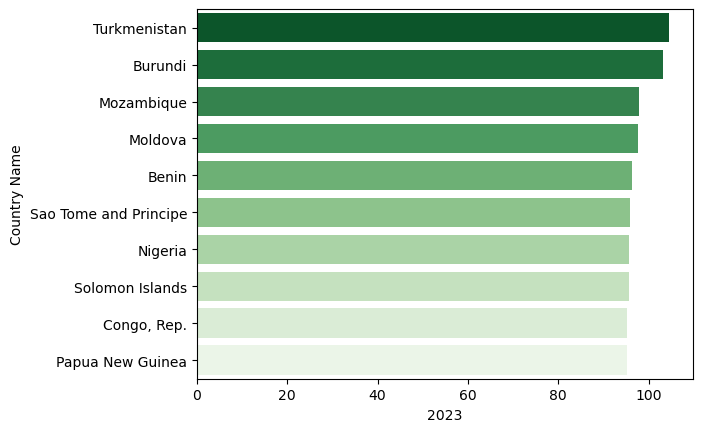

In [ ]:
top_10=df_f2mratio.nlargest(10, '2023')
sns.barplot(data=top_10, x='2023', y=top_10.index, palette='Greens_r')

и с самым низким

/var/folders/7z/02b8fxy15nvgyqr1w6c1n6bm0000gn/T/ipykernel_31080/2817476802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='2023', y=bottom_10.index, palette='Reds_r')


<Axes: xlabel='2023', ylabel='Country Name'>

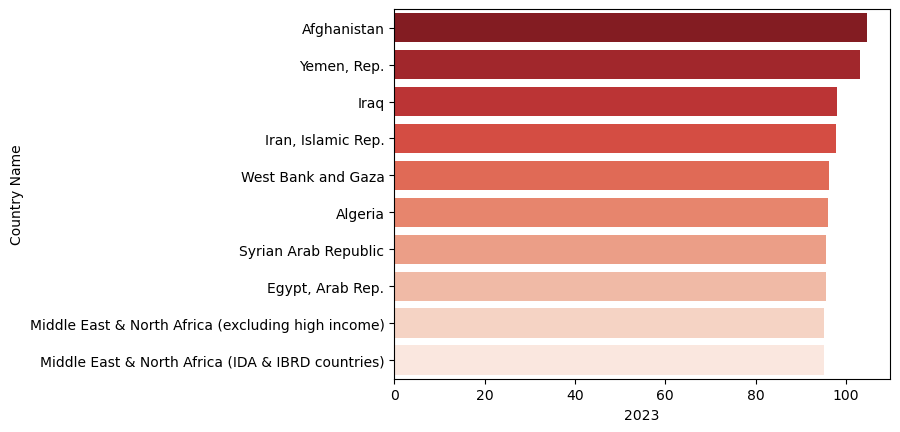

In [ ]:
bottom_10=df_f2mratio.nsmallest(10, '2023')
sns.barplot(data=top_10, x='2023', y=bottom_10.index, palette='Reds_r')

Отдельно посмотрим для США и крупных европейских стран, далее нам это пригодится 

In [ ]:
bigEU_data = df_f2mratio.loc[['France', 'Germany', 'United Kingdom', 'Spain', 'Sweden', 'Italy']]

In [ ]:
bigEU_data=bigEU_data.drop(bigEU_data.columns[0:3], axis=1)  

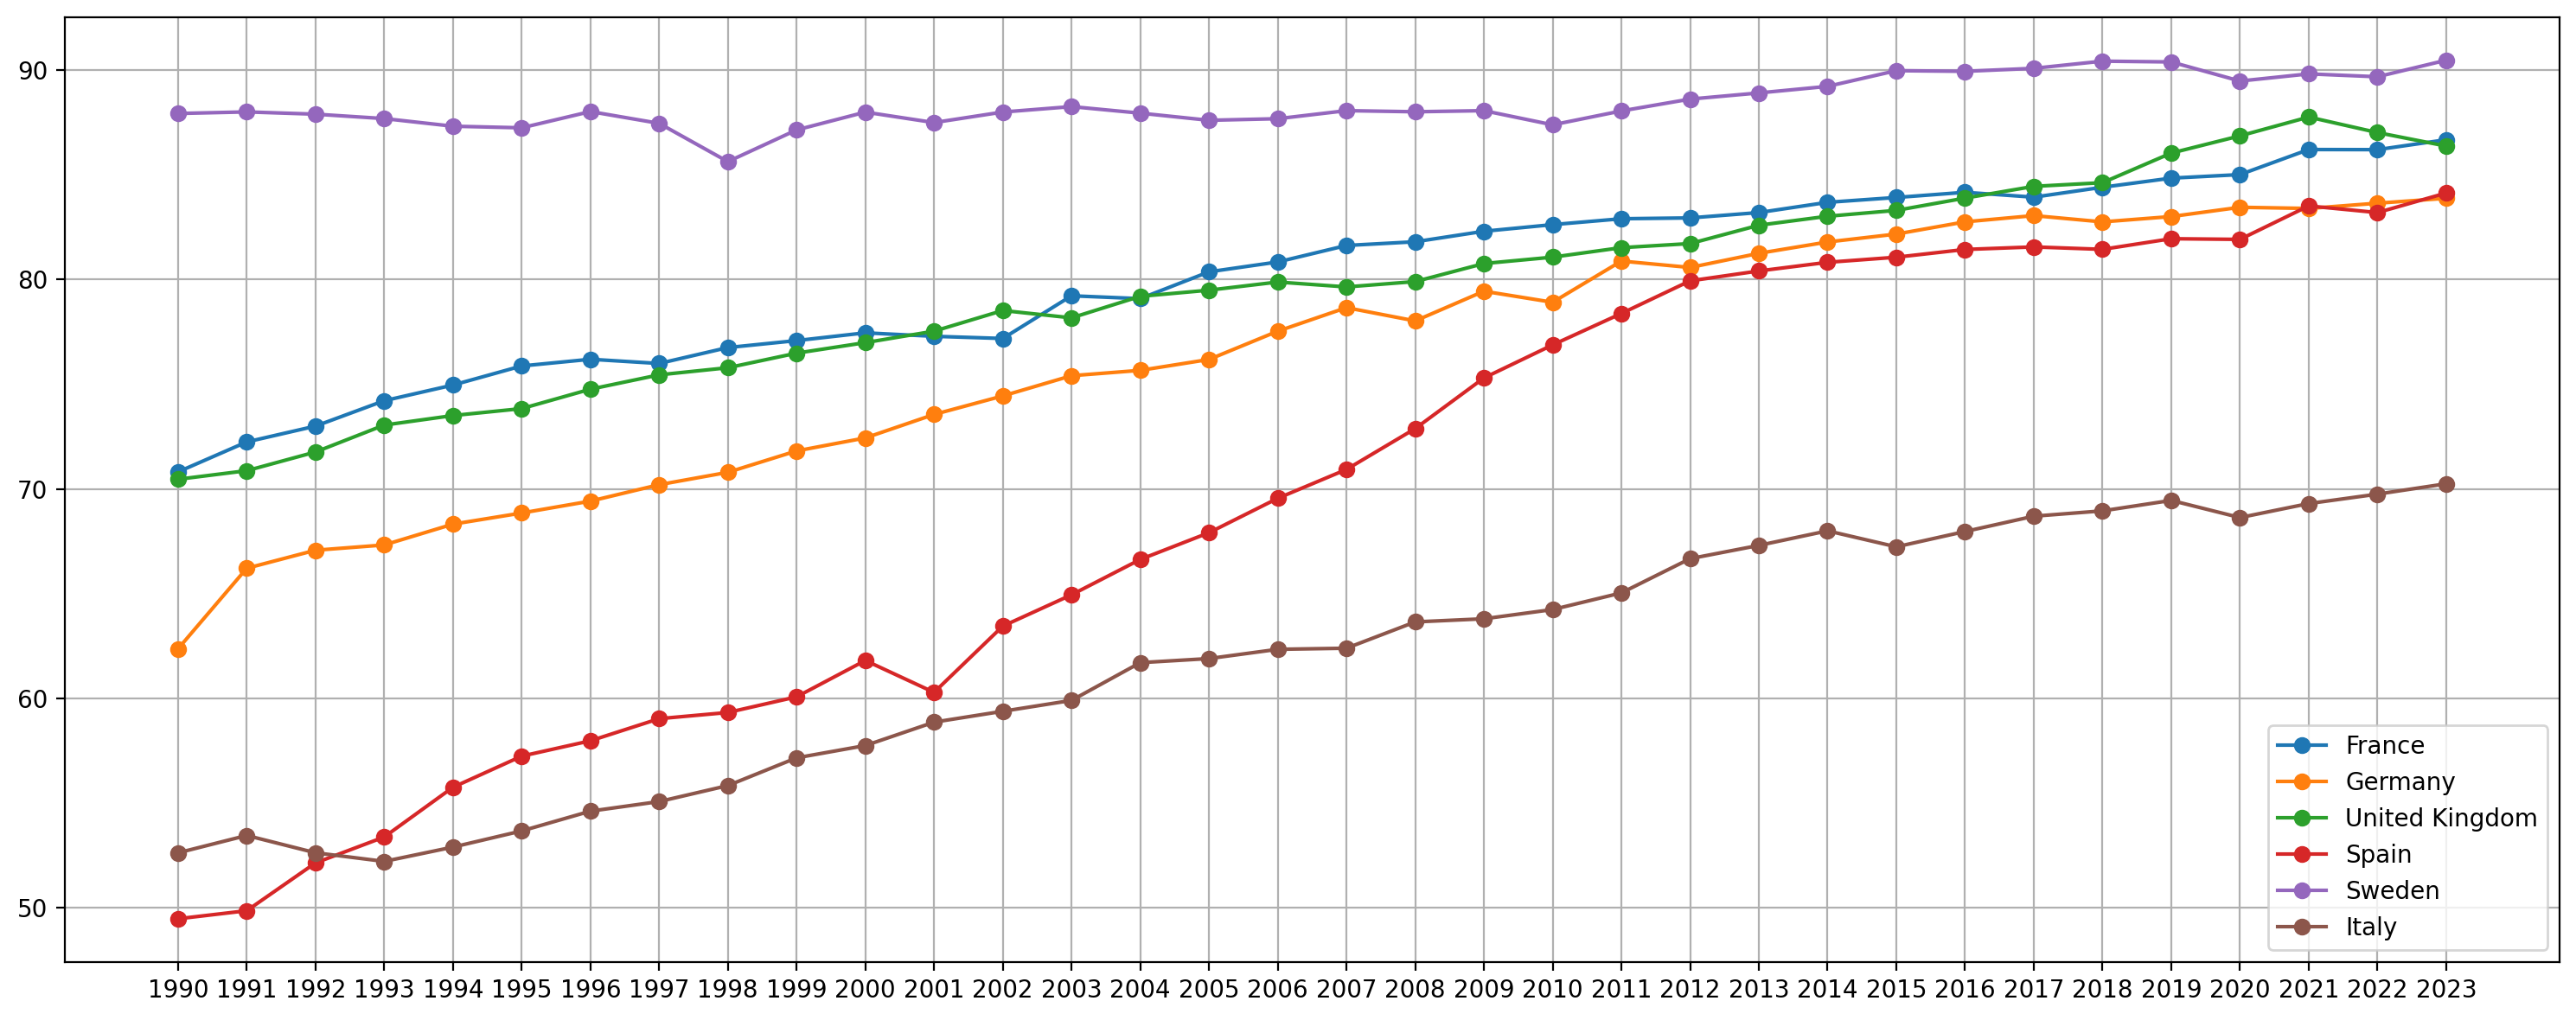

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
for country in bigEU_data.index:
    plt.plot(bigEU_data.loc[country], label=country, marker='o')
plt.tight_layout()
plt.grid(True)
plt.legend();

In [ ]:
East_EU_data=df_f2mratio.loc[['Poland', 'Romania', 'Ukraine', 'Estonia', 'Serbia', 'Hungary']]

In [ ]:
East_EU_data=East_EU_data.drop(East_EU_data.columns[0:3], axis=1) 

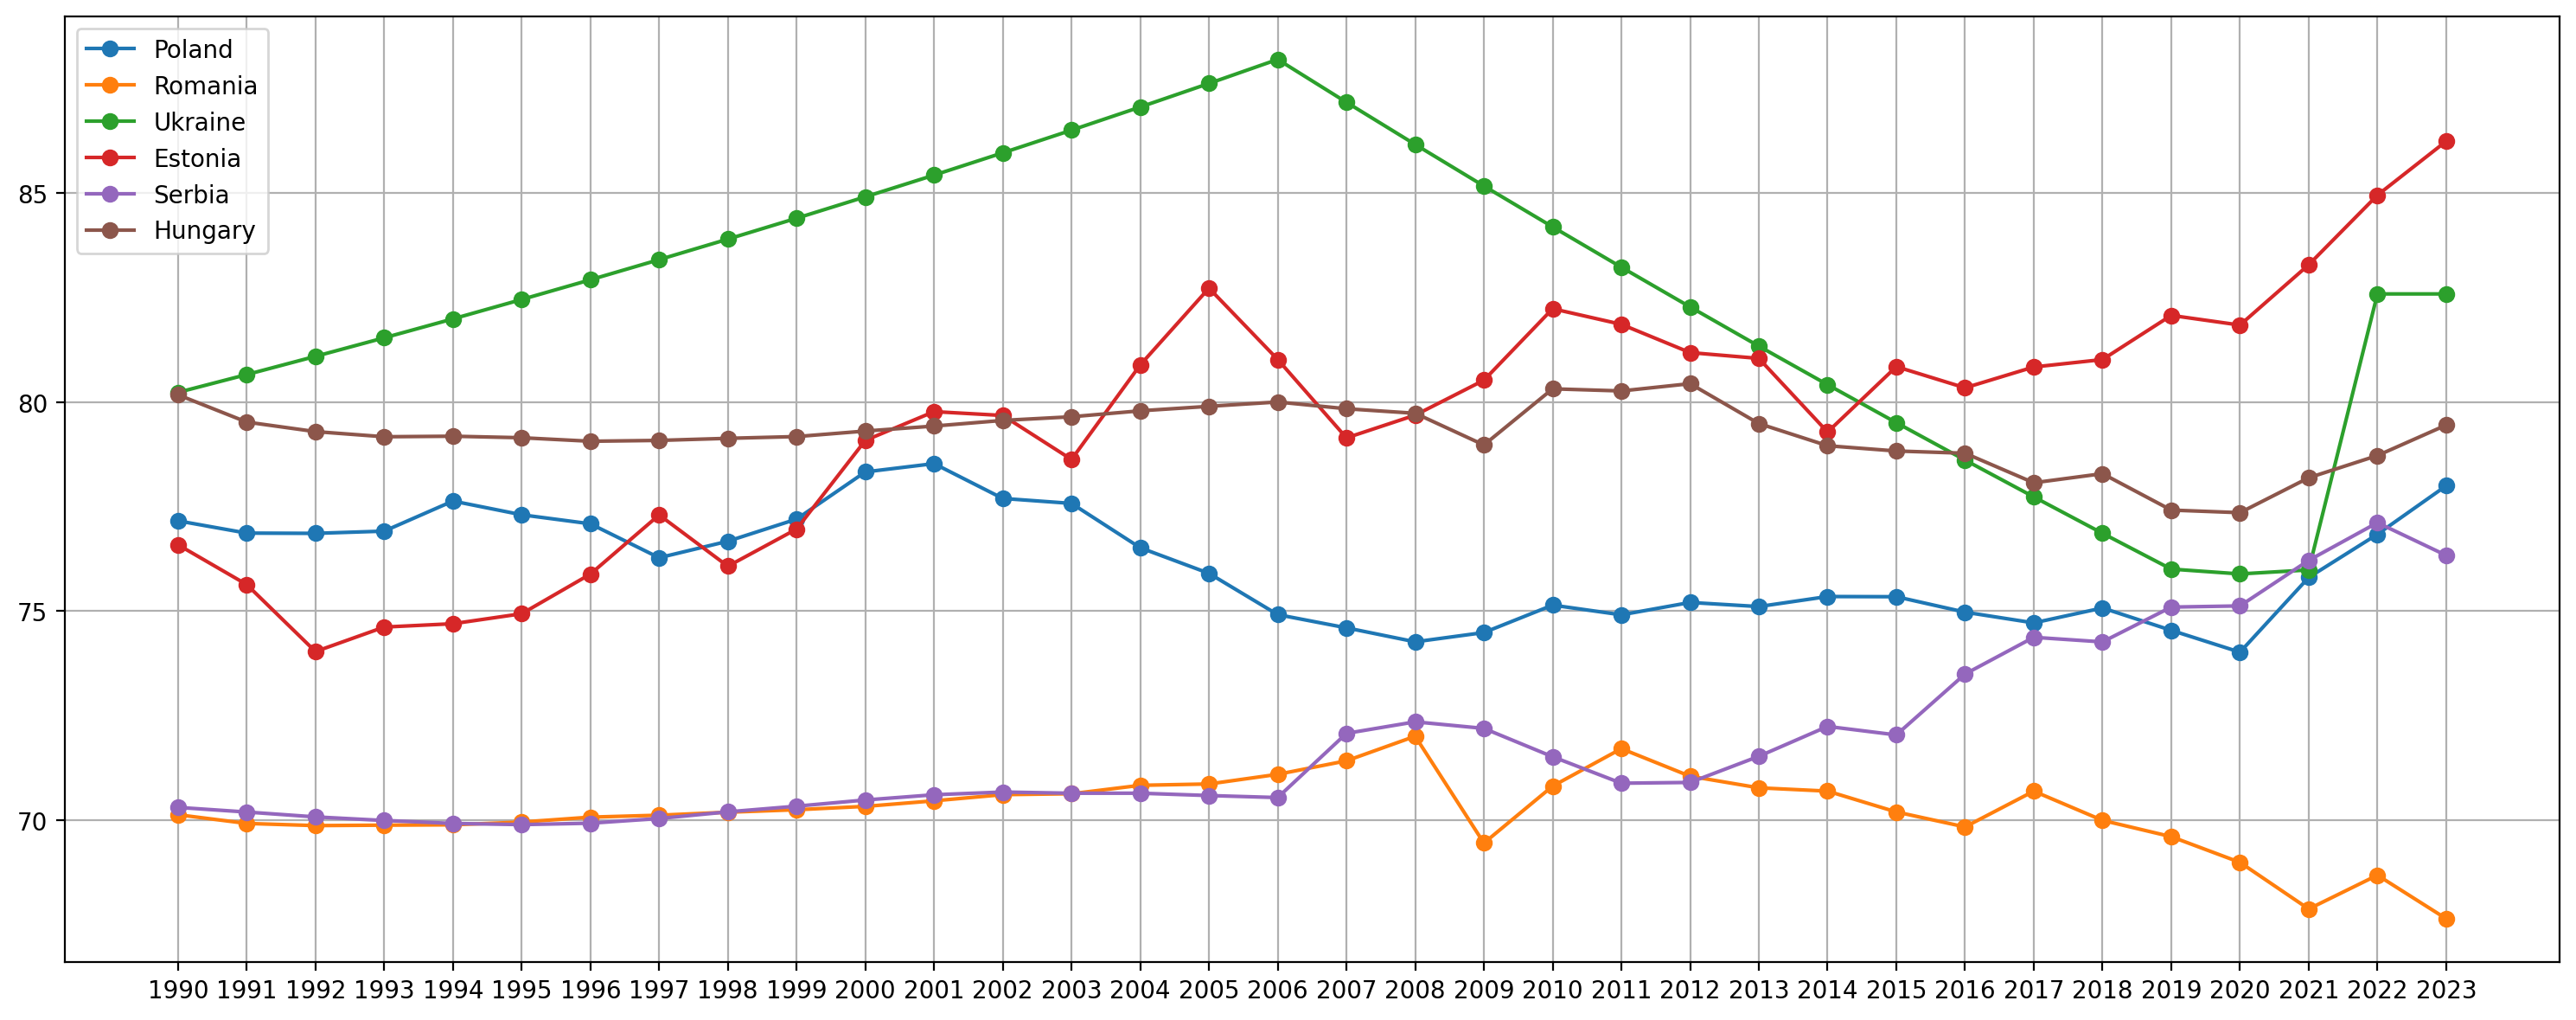

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
for country in East_EU_data.index:
    plt.plot(East_EU_data.loc[country], label=country, marker='o')
plt.tight_layout()
plt.grid(True)
plt.legend();

In [ ]:
us_data = df_f2mratio.loc['United States']

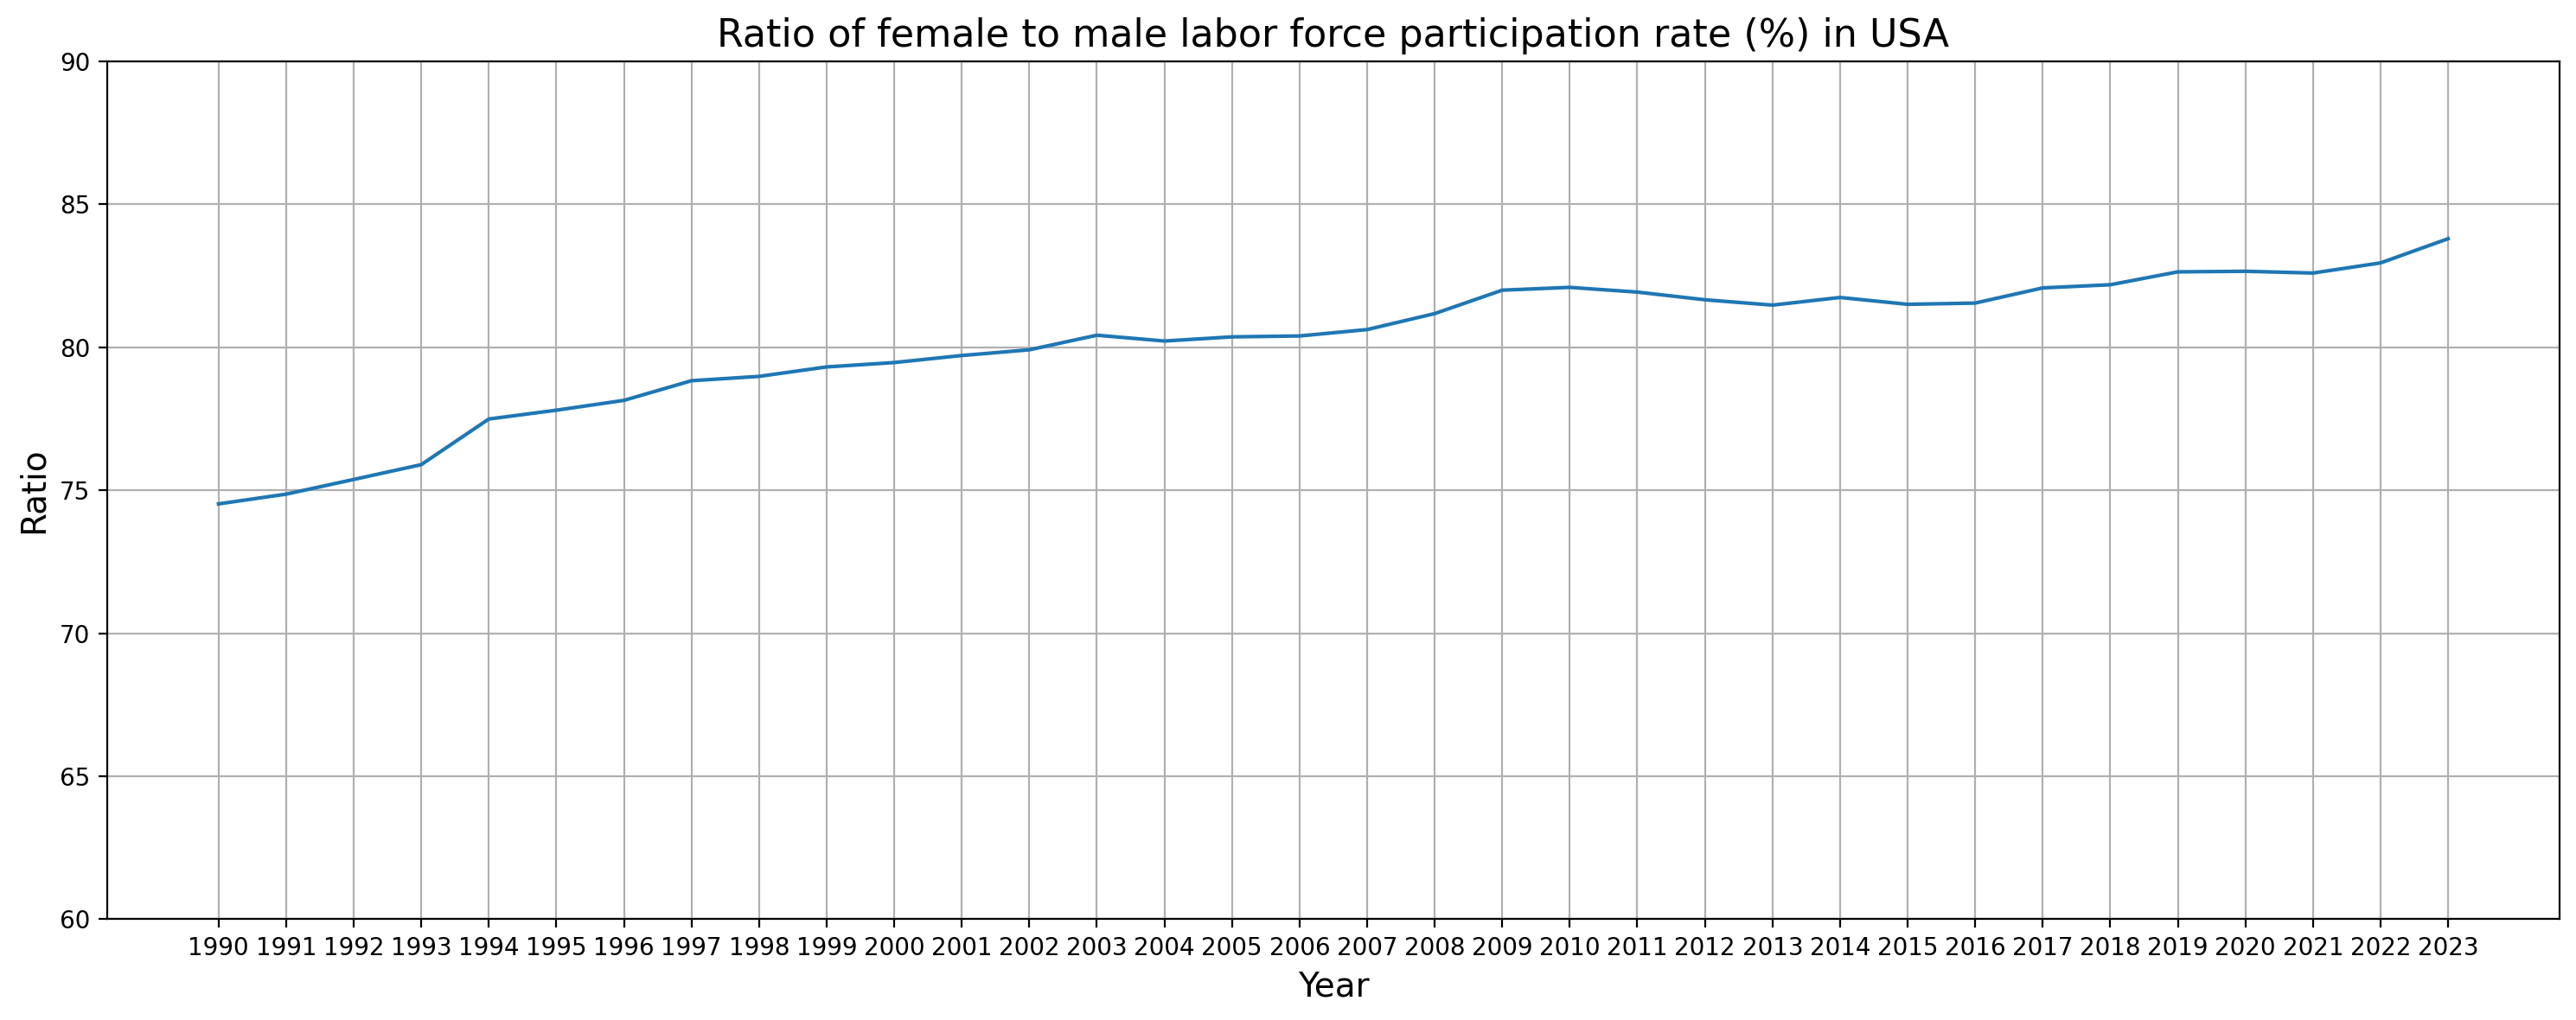

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
us_data=us_data[3:].reset_index()
us_data.columns = ['Year', 'Ratio']
sns.lineplot(data=us_data, x='Year', y='Ratio')
plt.title('Ratio of female to male labor force participation rate (%) in USA', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Ratio', fontsize=14)
plt.ylim(bottom=60, top=90) 
plt.tight_layout()
plt.grid(True)

Посмотрим схожую динамику для стран с самыми высокими и низкими показателями за последний год

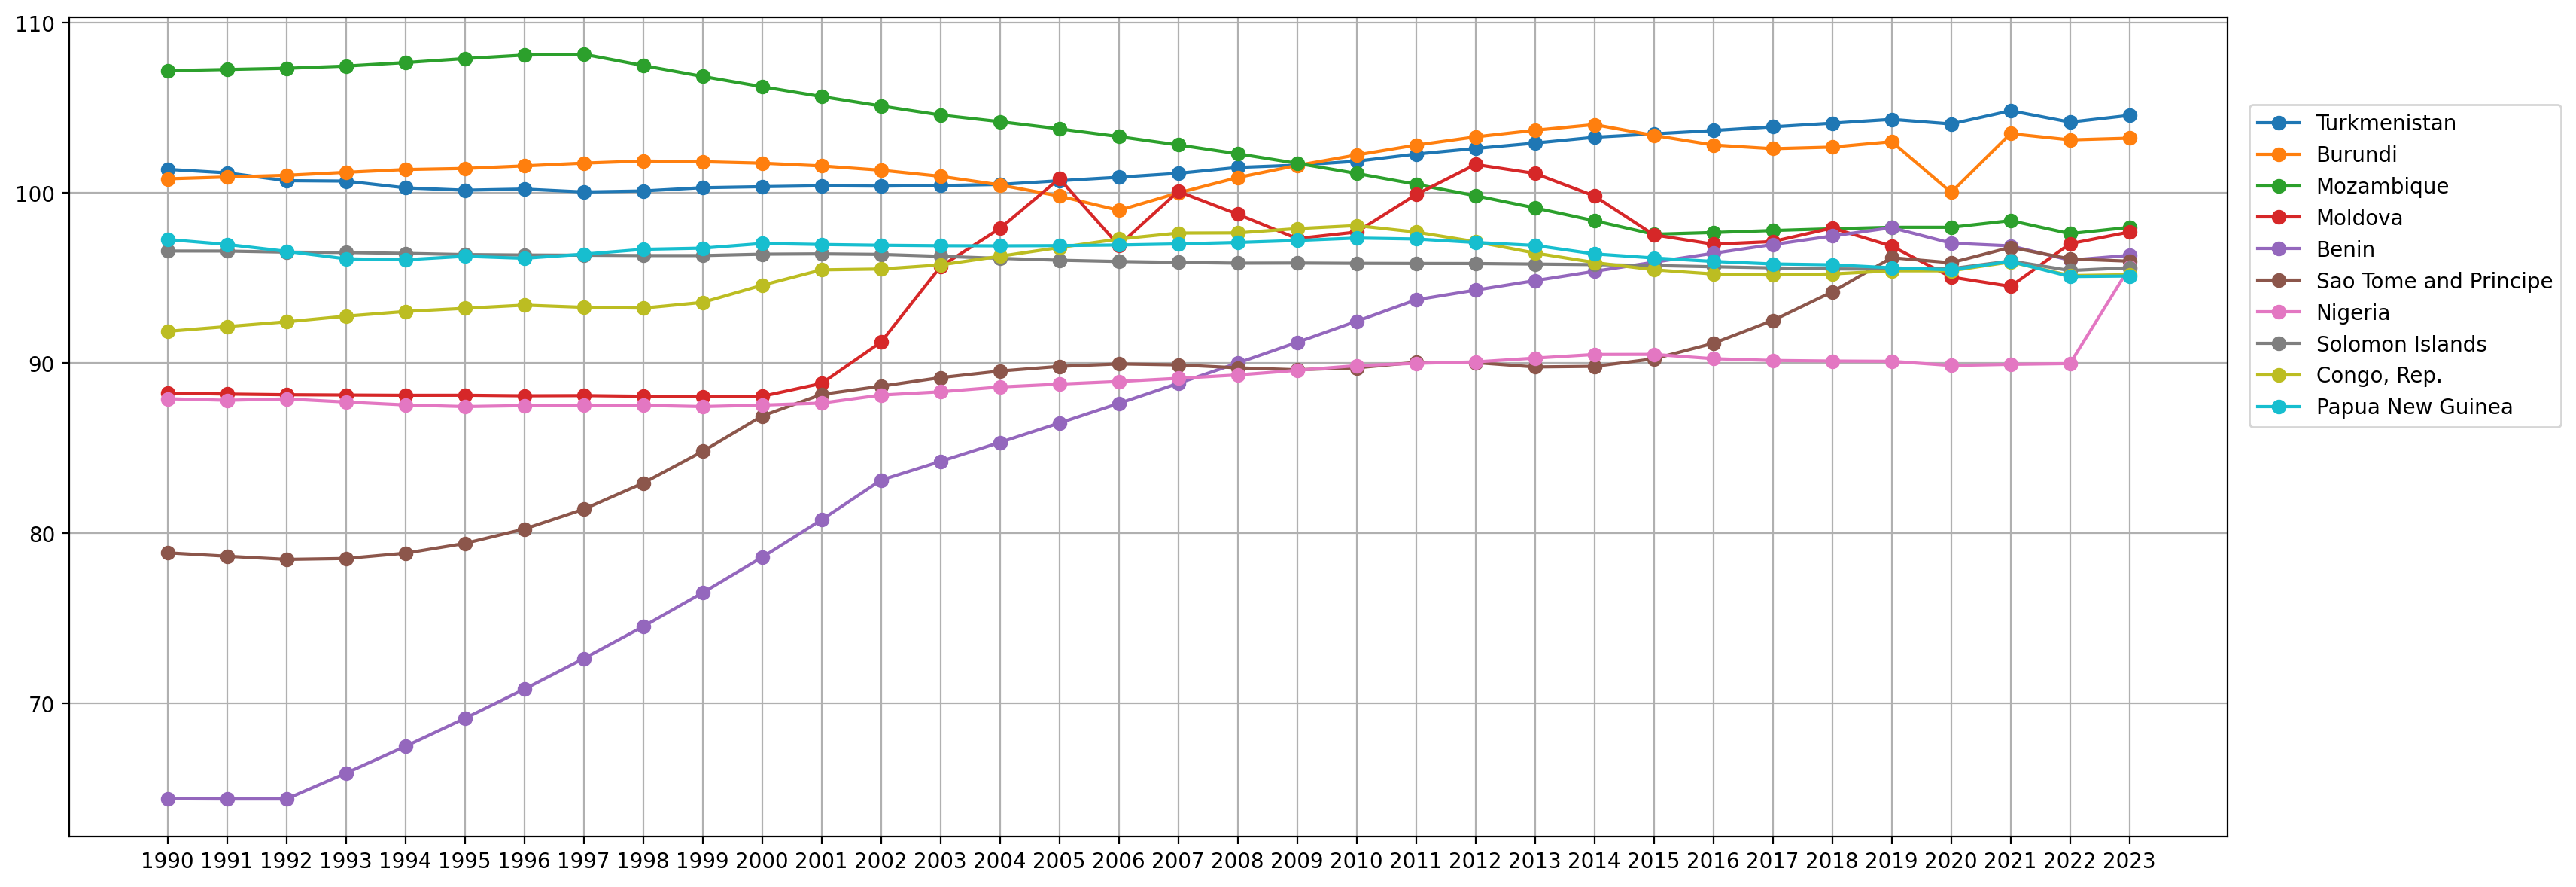

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
top_10 = top_10.drop(top_10.columns[0:3], axis=1)
for country in top_10.index:
    plt.plot(top_10.loc[country], label=country, marker='o')
plt.tight_layout()
plt.grid(True)
plt.legend(loc=(1.01, 0.5));

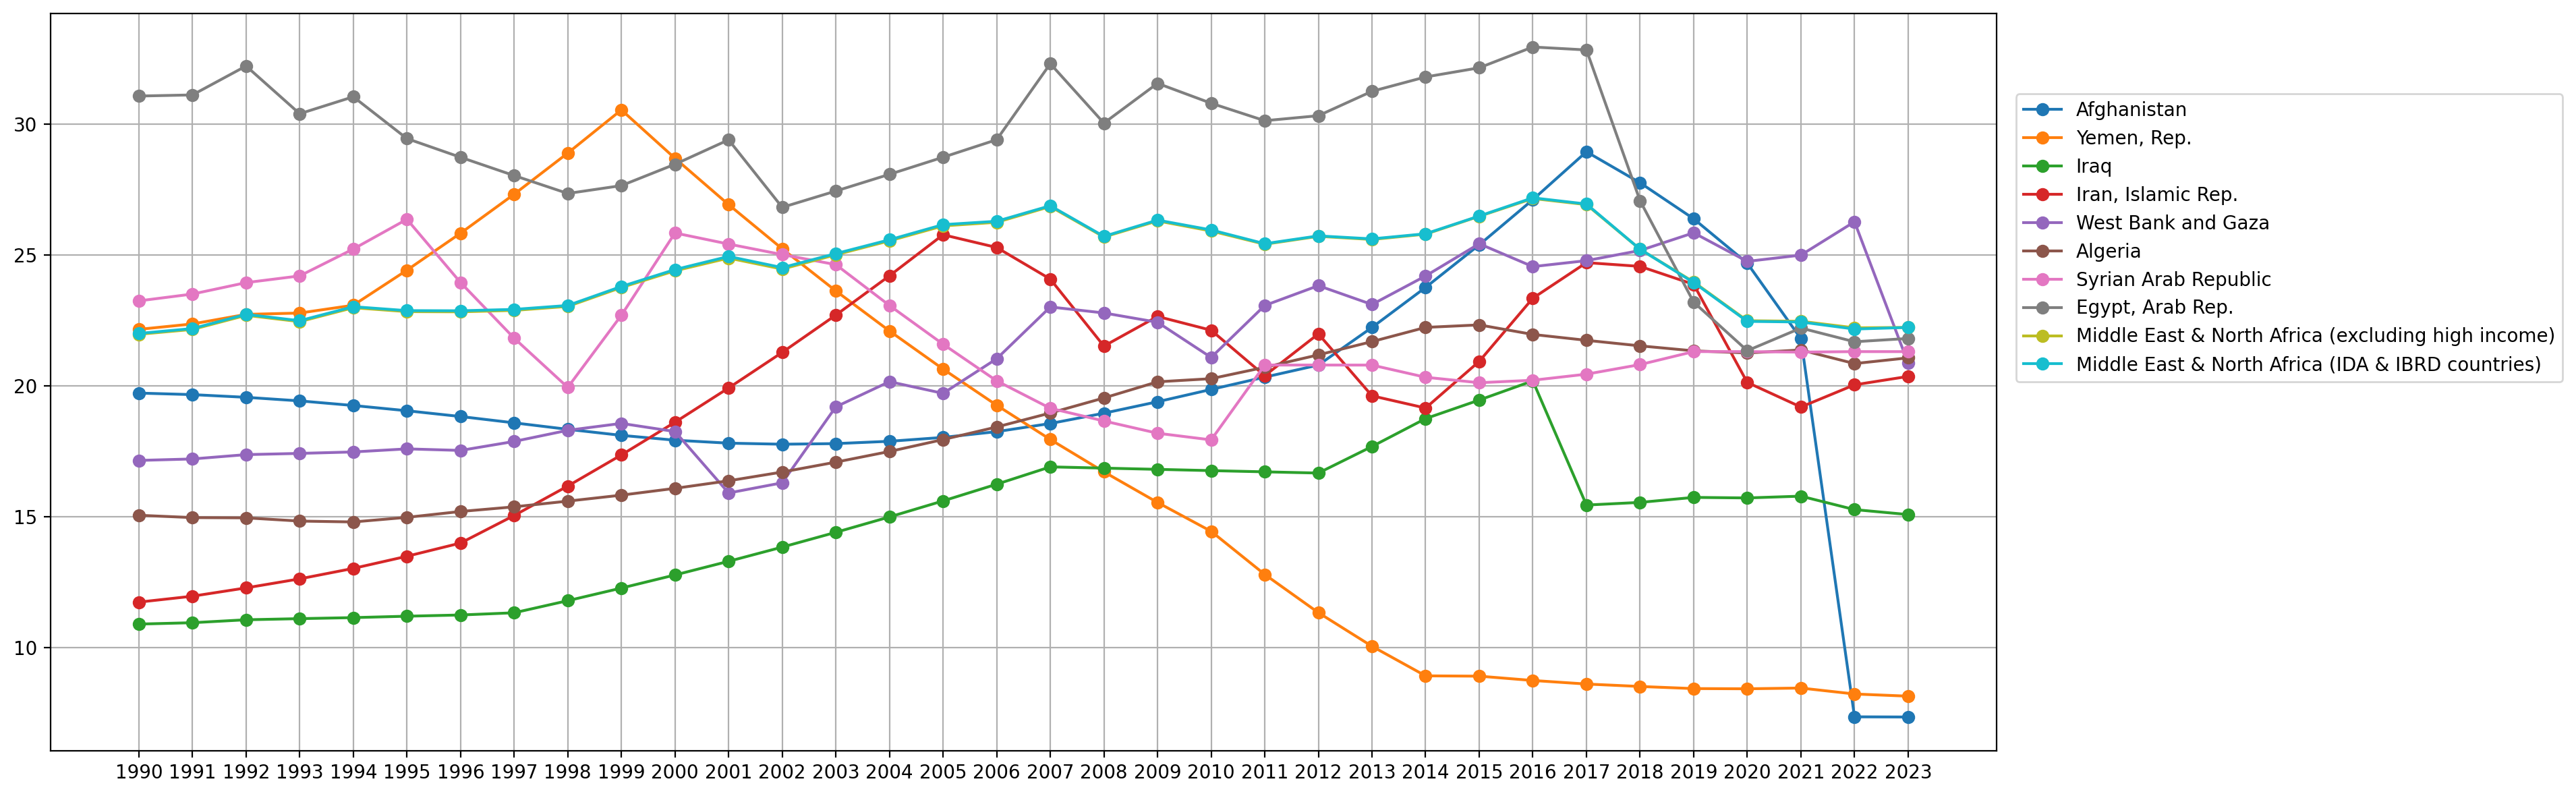

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
bottom_10=bottom_10.drop(bottom_10.columns[0:3], axis=1)
for country in bottom_10.index:
    plt.plot(bottom_10.loc[country], label=country, marker='o')
plt.tight_layout()
plt.grid(True)
plt.legend(loc=(1.01, 0.5)); 

Переходим к таблице df_population

In [ ]:
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 778780 entries, 0 to 778779
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Indicator Name  778780 non-null  object 
 1   Indicator Code  778780 non-null  object 
 2   Country Name    778780 non-null  object 
 3   Country Code    778780 non-null  object 
 4   Year            778780 non-null  int64  
 5   Value           778780 non-null  float64
 6   Disaggregation  778780 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 41.6+ MB


In [ ]:
df_population.head()

,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation
0,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2023,379025748.0,"female, All ages"
1,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2022,369655503.0,"female, All ages"
2,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2021,360249371.0,"female, All ages"
3,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2020,350869705.0,"female, All ages"
4,"Population, female",SP.POP.TOTL.FE.IN,Africa Eastern and Southern,AFE,2019,341569862.0,"female, All ages"


Так как у нас есть очень хорошие данные для США. Предлагаю рассматриваить их

In [ ]:
us_only=df_population[df_population['Country Name']=='United States']

/var/folders/7z/02b8fxy15nvgyqr1w6c1n6bm0000gn/T/ipykernel_31080/2767232679.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_us['Value']=total_us['Value'].apply(lambda x: np.round(x/10**6, 3))


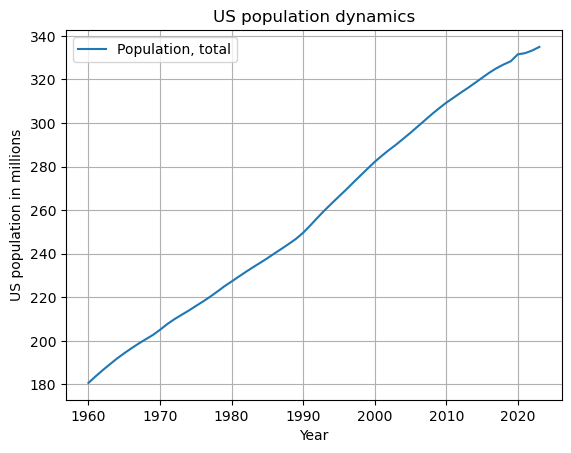

In [ ]:
total_us=us_only[us_only['Indicator Name']=='Population, total']
total_us['Value']=total_us['Value'].apply(lambda x: np.round(x/10**6, 3))
plt.plot(total_us['Year'], total_us['Value'], label='Population, total')
plt.title('US population dynamics')
plt.xlabel('Year')
plt.ylabel('US population in millions')
plt.grid(True)
plt.legend()

/var/folders/7z/02b8fxy15nvgyqr1w6c1n6bm0000gn/T/ipykernel_31080/1841515837.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female_usa['Value']=female_usa['Value'].apply(lambda x: np.round(x/10**6, 3))
/var/folders/7z/02b8fxy15nvgyqr1w6c1n6bm0000gn/T/ipykernel_31080/1841515837.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_usa['Value']=male_usa['Value'].apply(lambda x: np.round(x/10**6, 3))


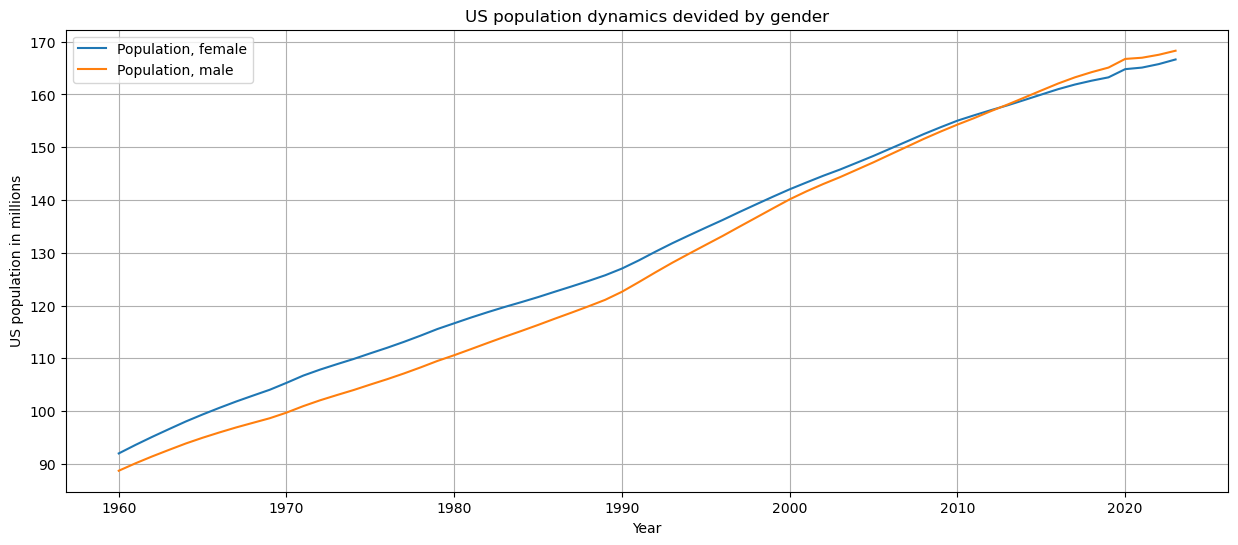

In [ ]:
# для удобства переведем колонку value в миллионы
female_usa=us_only[us_only['Indicator Name']=='Population, female']
female_usa['Value']=female_usa['Value'].apply(lambda x: np.round(x/10**6, 3))
plt.figure(figsize=(15, 6))
plt.plot(female_usa['Year'], female_usa['Value'], label='Population, female')

male_usa=us_only[us_only['Indicator Name']=='Population, male']
male_usa['Value']=male_usa['Value'].apply(lambda x: np.round(x/10**6, 3))
plt.plot(male_usa['Year'], male_usa['Value'], label='Population, male')
plt.title('US population dynamics devided by gender')
plt.xlabel('Year')
plt.ylabel('US population in millions')
plt.grid(True)
plt.legend();

Попроверяем различные гипотезы

Гипотеза 1: Разрыв в занятости между мужчинами и женщинами сокращается со временем
Метод:

Рассчитаем разрыв (разницу между уровнем занятости мужчин и женщин).
Построим график тренда.
Проверим значимость изменения среднего разрыва в разные десятилетия с помощью t-теста.

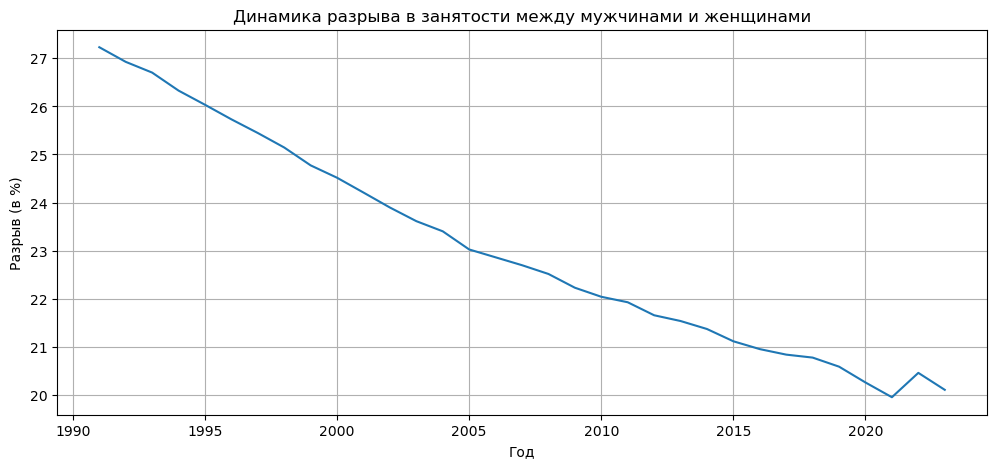

t-статистика: 11.15, p-значение: 0.0000
Разрыв в занятости значимо изменился после 2000 года.


In [ ]:
from scipy.stats import ttest_ind

# Фильтруем данные для показателей занятости мужчин и женщин
male_indicator = 'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)'
female_indicator = 'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)'

df_male = df_labour[df_labour['Indicator Name'] == male_indicator]
df_female = df_labour[df_labour['Indicator Name'] == female_indicator]

# Объединяем по странам и годам, рассчитываем разрыв
merged_df = df_male.merge(df_female, on=['Country Name', 'Year'], suffixes=('_male', '_female'))
merged_df['Gender Gap'] = merged_df['Value_male'] - merged_df['Value_female']

# Средний разрыв по годам
gap_trend = merged_df.groupby('Year')['Gender Gap'].mean()

# Визуализация динамики разрыва
plt.figure(figsize=(12, 5))
sns.lineplot(x=gap_trend.index, y=gap_trend.values)
plt.title("Динамика разрыва в занятости между мужчинами и женщинами")
plt.xlabel("Год")
plt.ylabel("Разрыв (в %)" )
plt.grid()
plt.show()

# Разделим данные на два периода и проверим t-тестом
early_period = merged_df[merged_df['Year'] < 2000]['Gender Gap']
late_period = merged_df[merged_df['Year'] >= 2000]['Gender Gap']

stat, p_value = ttest_ind(early_period.dropna(), late_period.dropna())
print(f"t-статистика: {stat:.2f}, p-значение: {p_value:.4f}")

if p_value < 0.05:
    print("Разрыв в занятости значимо изменился после 2000 года.")
else:
    print("Нет значимых изменений в разрыве до и после 2000 года.")
